# Set-up

## Load libraries

In [37]:
#Set directory
# install.packages("here")
library(here)
setwd(here())
#Install and load libraires
# invisible(source("./src/install_librairies.r"))
# install_packages(directory)
invisible(source("./src/load_librairies.r"))
# Load functions
invisible(source("./src/functions.r"))

## Load and clean dataset

In [2]:
#Load dataset
ca125 <- read.csv("./data/MAOV_ca125_all.csv", sep=";")
ca125 <- ca125%>%mutate(id=paste(trialid,"_",patid)) 
ca125 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)


n_patients,n_trials,n_measures
<int>,<int>,<int>
8219,13,102809


In [3]:
#Clean dataset
#check time between first surgery and first measure
Sys.setlocale("LC_TIME", "C")
ca125$delay_surg_trt<-(as.Date(toupper(ca125$dotrt_begin), format = "%d%b%Y")-as.Date(toupper(ca125$dosurg1), format = "%d%b%Y"))
#delete patients with delay <7
ca125<- ca125[!ca125$id %in% unique(ca125$id[ca125$delay_surg_trt < 7 & !is.na(ca125$delay_surg_trt)]),]

[1] "C"

In [4]:
# Clean first progression column
ca125 <- ca125 %>%
  mutate(
    dor = as.Date(toupper(dor), format = "%d%b%Y"),
    dofirst_prog = as.Date(toupper(dofirst_prog), format = "%d%b%Y"),
    dofirst_prog = if_else(
      is.na(dofirst_prog) & !is.na(dor),
      dor + pfs_time_m * 30.4375,
      dofirst_prog
    )
  )
ca125 <- ca125 %>%
  mutate(
    dotrt_begin = as.Date(toupper(dotrt_begin), format = "%d%b%Y"),
    donext_trt = as.Date(toupper(donext_trt), format = "%d%b%Y"),
    do_CA125 = as.Date(toupper(do_CA125), format = "%d%b%Y")
  )

In [5]:
#delete measures after progression 
ca125<-ca125 %>%
  filter( (trialid != "MRC-ICON7" & do_CA125 <= dofirst_prog) |
        (trialid == "MRC-ICON7" & time_ca125<=pfs_time_m * 30.4375))

In [6]:
ca125 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)

n_patients,n_trials,n_measures
<int>,<int>,<int>
8163,13,81449


In [7]:
#Create variables
ca125$trt_bin<- if_else(ca125$trt=="Standard regimen", 0,1)
ca125["os_time_d"]<-ca125$os_time_m*30.4375
ca125["pfs_time_d"]<-ca125$pfs_time_m*30.4375
ca125["os_statut"]<-factor(ifelse(ca125$os_status=='Yes', 1, 0), levels=c(0,1))
ca125["pfs_statut"]<-factor(ifelse(ca125$PFS_status=='Yes', 1, 0), levels=c(0,1))
#restrict data                             
colonnes<-c("trialid","patid","id",'trt','dor','CA125_mes','do_CA125','id_temp','dotrt_begin', "donext_trt",'dotrt_end',"time_ca125",'os_status','OS_time','PFS_status','PFS_time',"nb_mesures",
"ca125_base",'Visit','pfs_time_m',"pfs_time_d",'os_time_m',"os_time_d",'group','country','maov_group','dob','age','figo','figo4c',"trt_bin","os_statut","pfs_statut")
ca125_all_6 <- ca125[colonnes]%>%
  filter(time_ca125 <= 188) %>%
  group_by(id) %>%
  filter(n() > 1) %>%
  ungroup()
ca125_all_6["id_num"]<- as.numeric(as.factor(ca125_all_6$id))
ca125_all_6["trialid_num"]<- as.numeric(as.factor(ca125_all_6$trialid))
ca125_all_6["log_ca125"]<-log(ca125_all_6$CA125_mes)

In [8]:
ca125_all_6 %>% summarize(
    n_patients=n_distinct(id),
    n_trials=n_distinct(trialid),
    n_measures=n()
)

n_patients,n_trials,n_measures
<int>,<int>,<int>
7933,13,47256


**Summarise data**

In [9]:
ca125_all_6 %>%
  group_by(trialid) %>%
  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),

    # percentage deaths
    mean_ca125 = round(mean(CA125_mes, na.rm = TRUE),2),

     # percentage deaths
    mean_baseline = round(mean(ca125_base, na.rm = TRUE),2),
    
    
    # percentage deaths
    pct_death = round(mean(os_statut == 1, na.rm = TRUE) * 100,2),
    
    # percentage progression
    pct_progression = round(mean(pfs_statut == 1, na.rm = TRUE) * 100,2),
    
    # median OS time
    median_os_time_d = round(median(os_time_d, na.rm = TRUE),2),
    
    # median PFS time
    median_pfs_time_d = round(median(pfs_time_d, na.rm = TRUE),2),
    
    .groups = "drop"
  )

trialid,status,nb_measures,nb_patients,mean_ca125,mean_baseline,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,Maintenance,648,194,96.12,31.60,17.13,52.62,330.00,267.50
CCTG-OV.16,No maintenance,5517,731,222.35,721.71,72.05,84.74,1443.99,504.99
DoCaCel,Maintenance,40,19,186.32,346.38,72.50,77.50,995.50,374.50
EORTC-55041,Maintenance,1982,772,74.86,25.07,43.90,74.42,1351.00,424.00
GINECO-2007,Intensification therapy,613,109,313.07,870.53,83.85,92.50,975.00,445.00
JGOG-3016,Intensification therapy,3240,552,312.25,1022.00,46.57,65.25,1837.00,841.00
JGOG-3017,No maintenance,3497,608,67.62,129.05,18.84,26.19,1195.00,1100.00
MITO-7,Intensification therapy,1398,517,206.89,473.78,16.95,51.65,629.00,490.00
MRC-ICON7,Maintenance,10017,1471,113.08,376.65,46.14,71.46,1493.00,576.00


*Presentation of data and variables of interest (appendix)*

In [10]:
ca125_all_6 %>%  
  summarise(

    #status

    status= first(maov_group),
    
    #number of measures
    nb_measures = n(),
    
    # number of unique patients
    nb_patients = n_distinct(id),

    # percentage deaths
    mean_ca125 = round(mean(CA125_mes, na.rm = TRUE),2),
    
    # percentage deaths
    pct_death = round(mean(os_statut == 1, na.rm = TRUE) * 100,2),
    
    # percentage progression
    pct_progression = round(mean(pfs_statut == 1, na.rm = TRUE) * 100,2),
    
    # median OS time
    median_os_time_d = round(median(os_time_d, na.rm = TRUE),2),
    
    # median PFS time
    median_pfs_time_d = round(median(pfs_time_d, na.rm = TRUE),2),
    
    .groups = "drop"
  )

status,nb_measures,nb_patients,mean_ca125,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Intensification therapy,47256,7933,204.4,46.07,68.61,959,527


# Modeling CA125

## Evolution of CA-125

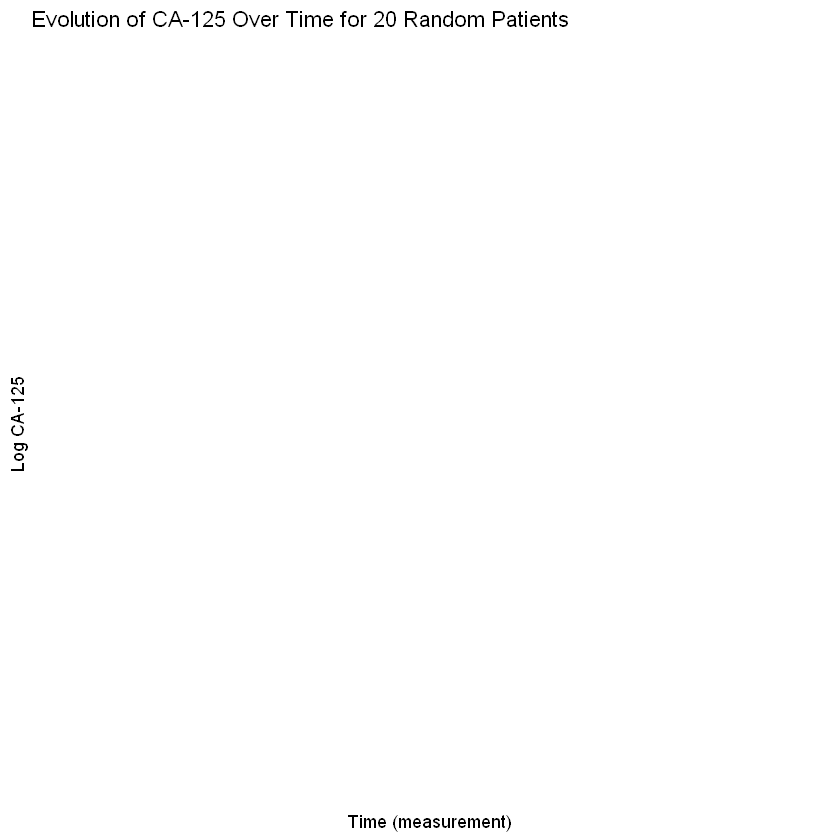

In [11]:
# set.seed(123)
# Select 20 random patients
selected_ids <- ca125_all_6 %>%
  distinct(id) %>%
  sample_n(20) %>%
  pull(id)
subset_data <- ca125_all_6[ca125_all_6$time_ca125<=90,] %>%
  filter(patid %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time for 20 Random Patients",
    x = "Time (measurement)", 
    y = "Log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")


In [12]:
# Compute trends per patient over 90 days of observation
df_trends_180 <- ca125_all_6%>%
  group_by(id) %>%
  summarise(trend_cat = trend(log_ca125, time_ca125), .groups = "drop")

# Join back to the original dataset
df_180 <- ca125_all_6 %>%
  left_join(df_trends_180, by = "id")
table(df_180$trend_cat)



decreasing increasing 
     43446       3810 

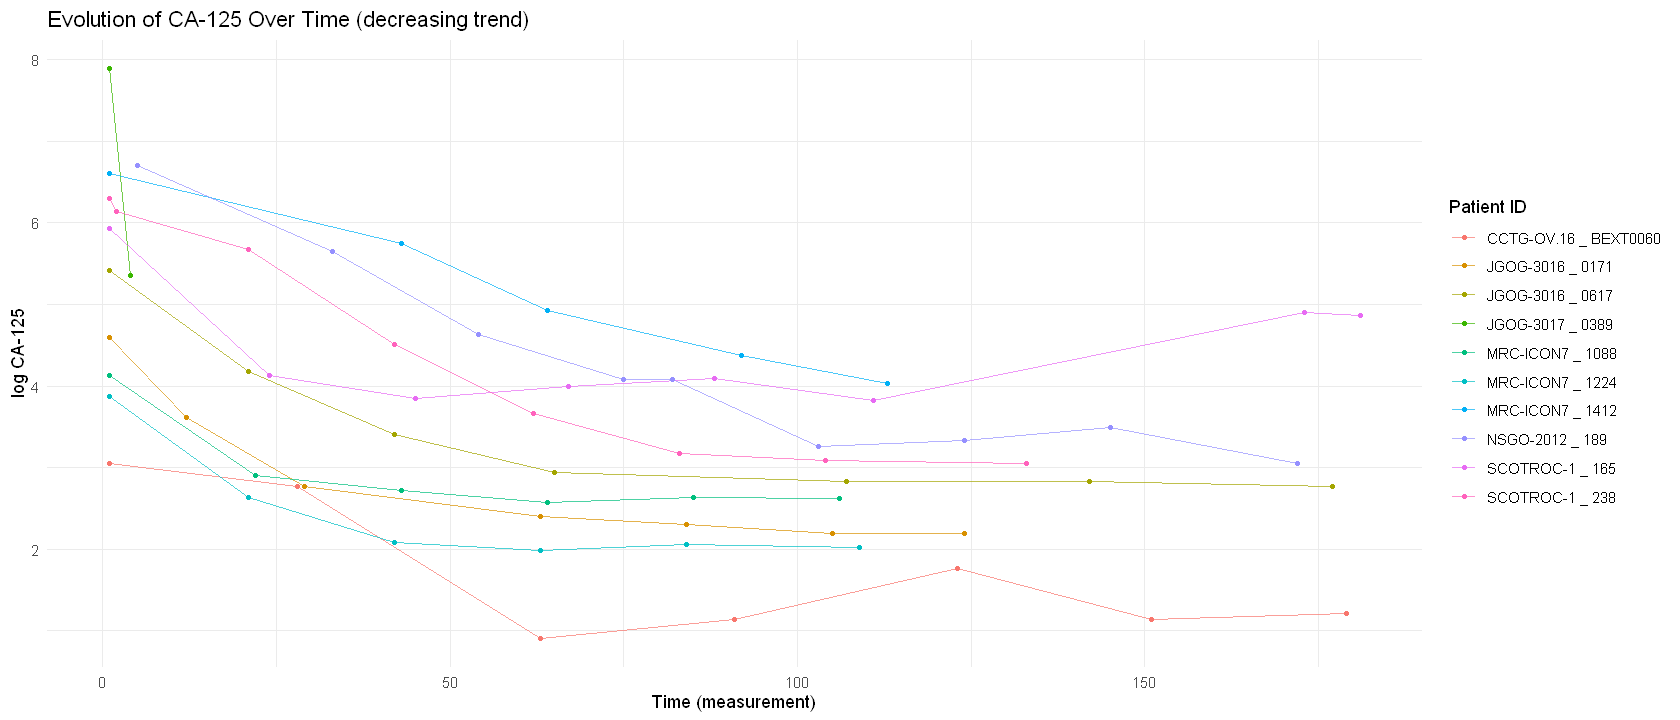

In [13]:
options(repr.plot.width = 14, repr.plot.height = 6)
selected_ids <- df_180[df_180$trend_cat=="decreasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (decreasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

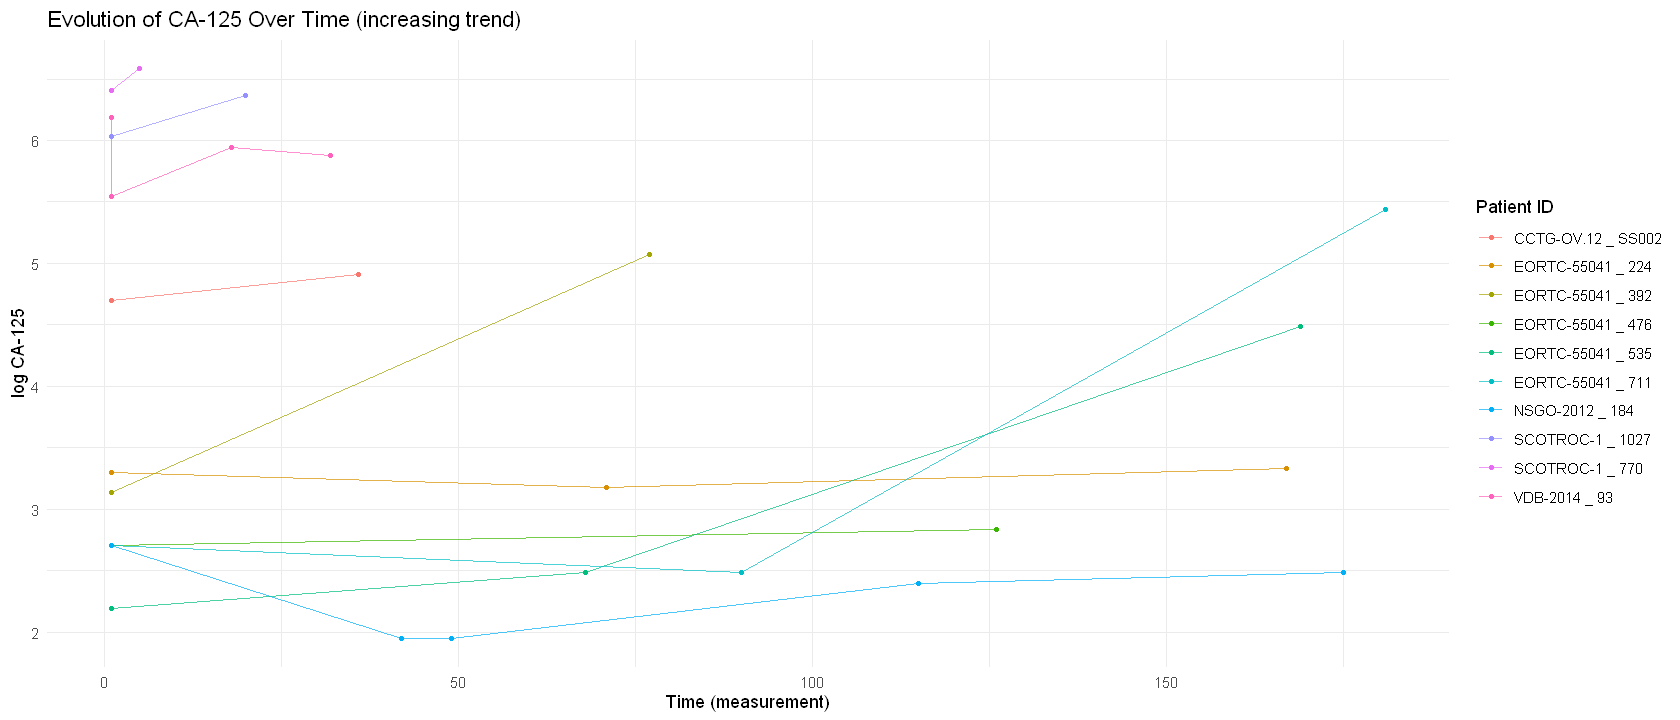

In [14]:
selected_ids <- df_180[df_180$trend_cat=="increasing",] %>%
  distinct(id) %>%
  sample_n(10) %>%
  pull(id)
subset_data <- df_180%>%
  filter(id %in% selected_ids)
# Plot longitudinal biomarker evolution
ggplot(subset_data, aes(x = time_ca125, y = log_ca125, color = id, group = id)) +
  geom_line(alpha = 0.7) +
  geom_point(size = 1) +
  labs(
    title = "Evolution of CA-125 Over Time (increasing trend)",
    x = "Time (measurement)", 
    y = "log CA-125",
    color = "Patient ID"
  ) +
  theme_minimal() +
  theme(legend.position = "right")

**Summarise CA-125 values**

In [15]:
ca125_all_6 %>%
  
  # keep repeated measures if you want ALL CA125 values
  group_by(trialid, trt) %>%
  
  summarise(
    
    n_measures = n(),
    n_patients = n_distinct(id),
    
    minca125 = min(CA125_mes, na.rm = TRUE),
    
    q1_ca125 = quantile(CA125_mes, 0.25, na.rm = TRUE),
    
    mean_ca125 = mean(CA125_mes, na.rm = TRUE),
    
    q3_ca125 = quantile(CA125_mes, 0.75, na.rm = TRUE),
    
    max_ca125 = max(CA125_mes, na.rm = TRUE),
        # percentage deaths
    pct_death = mean(os_statut == 1, na.rm = TRUE) * 100,
    # percentage progression
    pct_progression = mean(pfs_statut == 1, na.rm = TRUE) * 100,
    # median OS time
    median_os_time_d = median(os_time_d, na.rm = TRUE),
    # median PFS time
    median_pfs_time_d = median(pfs_time_d, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  
  arrange(trialid, trt)

trialid,trt,n_measures,n_patients,minca125,q1_ca125,mean_ca125,q3_ca125,max_ca125,pct_death,pct_progression,median_os_time_d,median_pfs_time_d
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
CCTG-OV.12,Investigational regimen,326,98,1.00,7.270,63.48276,27.675,3865.0,13.19018,56.74847,332.0001,265.9994
CCTG-OV.12,Standard regimen,322,96,0.60,7.000,129.15689,28.850,7027.0,21.11801,48.44720,327.9991,269.0005
CCTG-OV.16,Investigational regimen,2711,372,0.39,11.000,254.31692,128.000,12083.0,72.44559,85.06086,1457.9867,482.0083
CCTG-OV.16,Standard regimen,2806,359,0.21,11.000,191.45644,94.525,11800.0,71.66785,84.42623,1439.9981,524.0120
DoCaCel,Investigational regimen,16,8,7.00,9.000,126.43750,53.750,1046.0,62.50000,62.50000,791.0000,354.0000
DoCaCel,Standard regimen,24,11,9.00,11.000,226.25000,156.000,2100.0,79.16667,87.50000,1352.0000,374.5000
EORTC-55041,Investigational regimen,993,388,1.00,8.000,58.35952,23.000,3812.0,46.42497,76.33434,1340.0000,408.0000
EORTC-55041,Standard regimen,989,384,1.00,7.000,91.42568,23.000,14220.0,41.35490,72.49747,1372.0000,434.0000
GINECO-2007,Investigational regimen,292,48,4.00,16.000,253.08925,196.500,5180.0,86.98630,96.57534,1026.0000,490.0000


*Variables of interest per treatment group* 

# Joint modeling

**Longitudinal model**
$
Y_i(t) = (\beta_0 +b_{0i})+ \sum_{k=1}^{3} (\beta_k+b_{ki}) \, ns_k(t)+ \sum_{k=1}^{3} \gamma_k \, ns_k(t)*T_i+ \varepsilon_i(t)
$

$
b_i \sim \mathcal{N}(0, D), \quad \varepsilon_i(t) \sim \mathcal{N}(0, \sigma^2)
$\
**Survival model**
$
h_i(t) = h_0(t)\exp(\alpha \, T_i)
$

$
h_0(t) = \sum_{m=1}^{M} \lambda_m B_m(t)
$

**Joint association structure**

$
h_i(t \mid b_i) = h_0(t)\exp(\alpha \, T_i + \eta^\top b_i)
$\
**Full likelihood**

$
L = \prod_{i=1}^N 
\int 
f(Y_i \mid b_i)\,
f(T_i, \delta_i \mid b_i)\,
f(b_i)\, db_i
$

## One model per trial



With splines :
- s trials
- $n_i$ patients in trial $i$, $n = \sum_{i=1}^{s} n_i$ the total number of patients
- $m_{ij}$ the number of measures for patient j in study i, $m_{i}=\sum_{j=1}^{n_i} m_{ij}$ the total number of observations in trial $i$, $N=\sum_{i=1}^{s} m_i=\sum_{i=1}^{s}\sum_{j=1}^{n_i} m_{ij}$ the total number of observations
- $y(t_{ijk})$ the $k^{th}$ value $k \in {1,...,m_{ij}}$ of biomarker CA-125 for patient $j$, $j \in {1,...,n_i}$, in study $i$, $i \in {1,...,s}$
- 
$$
T_{ij}=
\begin{cases} 
1 & \text{if patient $j$ in trial $i$ received the treatment} 
\\ 0 & \text{otherwise}
\end{cases}
$$

Mixed-effects model for varataion of $y_i$ in trial $i \in {1,...,s}$ :
$
log[y_i(t_{ijk})]= f_i(t_{ijk}) +\epsilon_{ijk}
$, 
with:
- $ f_i(t)= (\theta_{i1}+b_{1ij}) + (\theta_{i4}+b_{4ij})t+ \sum_{k=0}^1 (\theta_{ik+2}+ b_{k+2,ij})B_{k+2}(t)+ \theta_{i5}T_{ij}*t+ \sum_{k=0}^1 \theta_{ik+6} T_{ij}*B_{k+2}(t)$; $B_{k+2}(t) = d_{k} - d_2; d_k=\frac{(t-q_k(t))_{+}^3 - (t-q_3(t))_{+}^3}{q_k(t) - q_3(t)} \text{ , } k \in\ \{0,1\}$
- $x_+ = max (0, x)  $,
- $q_0(t), q_1(t), q_2(t) \text{ and } q_3(t)  \text{ are quantiles of t at 18\%, 22\%, 66\%, and 98\%} $
- $ (b_{1ij},b_{4ij},b_{2ij}, b_{3ij})^t \sim N(0, D)$, $D = \begin{pmatrix} \sigma_{b1}^2 & \sigma_{b1b4} & \sigma_{b1b2} & \sigma_{b1b3} \\ \sigma_{b1b4} & \sigma_{b4}^2 &  \sigma_{b2b4} & \sigma_{b3b4} \\ \sigma_{b1b2} & \sigma_{b2b4} &\sigma_{b2}^2 & \sigma_{b2b3} \\ \sigma_{b1b3} & \sigma_{b3b4} & \sigma_{b2b3} & \sigma_{b3}^2 \end{pmatrix}$(random effects at patient-level)
- $\epsilon_{ijk} \sim N(0, \sigma^2_\epsilon I_{m_i})$


**Conditional BLUP for patient-level random effects**:

- $\theta_i=(\theta_{i1} \text{  } \theta_{i4} \text{  } \theta_{i2} \text{  } \theta_{i3} \text{  } \theta_{i5} \text{  } \theta_{i6} \text{  } \theta_{i7})^T$

Matricial form: $ y_i= X_i\theta_i + Z_{n_i}b_{n_i} + \epsilon_i$, with :
$
y_i =
\begin{pmatrix}
y(t_{i11}) \\
y(t_{i12}) \\
\vdots \\
y(t_{i1 m_{i1}}) \\
y(t_{i21}) \\
\vdots \\
y(t_{i n_i m_{in_im_i}})
\end{pmatrix}
\in \mathbb{R}^{m_i},
\qquad
$,
$
X_i =
\begin{pmatrix}
1 & t_{i11} & B_2(t_{i11}) & B_3(t_{i11}) & T_{i1}*t_{i11} & T_{i1}*B_2(t_{i11}) & T_{i1}*B_3(t_{i11}) \\
1 & t_{i12} & B_2(t_{i12}) & B_3(t_{i12}) & T_{i1}*t_{i12} & T_{i1}*B_2(t_{i12}) & T_{i1}*B_3(t_{i12}) \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
1 & t_{i n_i m_i} & B_2(t_{i n_i m_i}) & B_3(t_{i n_i m_i}) & T_{in_i}*t_{i n_i m_i} & T_{in_i}*B_2(t_{i n_i m_i}) & T_{in_i}*B_3(t_{i n_i m_i})
\end{pmatrix}
\in \mathbb{R}^{m_i \times 7}
$
- $b_{n_i} \sim N(0, \Delta_i)$ (patient-level random intercept+slope), $
\Delta_i = \mathrm{diag}(D_i,...,D_i) \in \mathbb{R}^{4n_i \times 4n_i}
$

$$
b_{n_i} =
\begin{pmatrix}
b_{1,i1} \\
b_{4,i1} \\
b_{2,i1} \\
b_{3,i1} \\
b_{1,i2} \\
b_{4,i2} \\
b_{2,i2} \\
b_{3,i2} \\
\vdots \\
b_{1,i n_i} \\
b_{4,i n_i} \\
b_{2,i n_i}\\
b_{3,i n_i}
\end{pmatrix}
\in \mathbb{R}^{4n_i},
\qquad
$$

- $\epsilon_i \sim N(0, \sigma^2_{\epsilon}I_{m_i})$

$\boxed{Var(y_i)=V_i= Z_{n_i}\Delta_i Z_{n_i}^T + \sigma^2_{\epsilon}I_N}$\
with, for patient $(i,j)$,:

$
Z_{ij}=\begin{pmatrix}1 & t_{ij1} & B_2(t_{ij1}) & B_3(t_{ij1})\\1 & t_{ij2}&  B_2(t_{ij2}) & B_3(t_{ij2})\\\vdots & \vdots & \vdots\\1 & t_{ijm_{ij}}& B_2(t_{ijm_{ij}}) & B_3(t_{ijm_{ij}})\end{pmatrix}\in \mathbb{R}^{m_{ij} \times 4}$, 
$
Z_{n}=\begin{pmatrix}Z_{11} & 0 & \cdots & 0\\0 & Z_{12} & \cdots & 0\\\vdots & \vdots & \ddots & \vdots\\0 & 0 & \cdots & Z_{s n_s}\end{pmatrix} \in \mathbb{R}^{N \times 4n}
$

$$
\widehat{b}_{n_i} = \Delta_i Z_{n_i}^\top V_i^{-1}(y_i-X_i\hat{\theta_i})
$$
$
\begin{pmatrix}
\hat b_{1ij} \\
\hat b_{4ij} \\
\hat b_{2ij}\\
\hat b_{3ij}
\end{pmatrix}
=[\Delta]_{ij}\sum_{k=1}^{m_{ij}}\begin{pmatrix}1\\ t_{ijk} \\B_2(t_{ijk}) \\B_3(t_{ijk})\end{pmatrix}\,\bigl[V_i^{-1}(y_i - X_i\hat\theta_i)\bigr]_{jk}
$

**Fixed Effects Estimate**\
Stack all data across studies:
$$
\hat{\beta} = (\mathbf{X}^\top \mathbf{V}^{-1} \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{V}^{-1} \mathbf{y}
$$

In [16]:
#Set up model
internal_knots <- quantile(ca125_all_6$time_ca125, probs = c(0.22,0.66))
boundary_knots <- quantile(ca125_all_6$time_ca125, probs = c(0.18,0.98))
ns_basis <- ns(ca125_all_6$time_ca125,knots = internal_knots,Boundary.knots = boundary_knots)
ca125_all_6["id_num"]<- as.integer(as.numeric(as.factor(ca125_all_6$id)))
ca125_all_6["trialid_num"]<- as.integer(as.numeric(as.factor(ca125_all_6$trialid)))
ca125_all_6["log_ca125"]<-log(ca125_all_6$CA125_mes)

In [17]:
#Load kelim data
kelim <- read.csv("./data/data_GCIG_KELIM_survie.csv", sep=";")
kelim <- kelim%>%rename(id=ID_unique)%>%
                 mutate(trt_bin=as.factor(if_else(ttt_arm=="ctrl", 0,1))) %>%
                 select(id,trial_name,trt_bin, KELIM_continuous,KELIM_score,OS_status,OS_time,PFS_status,PFS_time)
print(paste0(c("Number of patients:", nrow(kelim))))
print(paste0(c("Number of trials:", length(unique(kelim$trial_name)))))

[1] "Number of patients:" "5884"               
[1] "Number of trials:" "8"                


In [ ]:
ca125_all_6<-ca125_all_6 %>%arrange(id_num)
trial_list <- split(ca125_all_6, ca125_all_6$trialid)
# -----------------------------
# storage
# -----------------------------

results_list <- list()
weekly_predictions<-list()
average_values<-list()
model_store <- list()
nadirs<-list()
nadirs_week<-list()
wald_list <-list()

# -----------------------------
# loop
# -----------------------------

for (trial_name in names(trial_list)) {

  cat("Fitting:", trial_name, "\n")
  
  # Filter dataset for the current trial
  df <- trial_list[[trial_name]]

  # -------------------------
  # spline basis
  # -------------------------
  internal_knots <- quantile(df$time_ca125, c(0.22, 0.66))
  boundary_knots <- quantile(df$time_ca125, c(0.18, 0.98))

  ns_basis <- ns(df$time_ca125,
                 knots = internal_knots,
                 Boundary.knots = boundary_knots)

  colnames(ns_basis) <- paste0("ns", 1:ncol(ns_basis))
  df <- cbind(df, ns_basis)
  df$week <- round(df$time_ca125/7)

  # -------------------------
  # model
  # -------------------------
  model <- tryCatch({

    Jointlcmm(
      fixed = log_ca125 ~ ns1 + ns2 + ns3 +
        trt_bin:(ns1 + ns2 + ns3),
      random = ~ ns1 + ns2 + ns3,
      subject = "id_num",
      ng = 1,
      survival = Surv(pfs_time_d, pfs_statut) ~ trt_bin,
      hazard = "splines",
      data = df,
      maxiter = 1500
    )
  
  }, error = function(e) NULL)

  if (is.null(model)) next
  model_coefs<-model$best
  log_ca125_pred <- predictY(model,newdata = df,var.time = "time_ca125")$pred
  weekly_prediction <- tryCatch({
    ca125_patient <- data.frame(trialid = trial_name,
                                trt=df$trt_bin,
                                log_ca125=as.vector(df$log_ca125),
                                week=df$week, 
                                log_ca125_pred =as.vector(log_ca125_pred)) %>%
      group_by(trialid, trt, week) %>%
      summarise(
        log_ca125_pred_week =
          mean(
            log_ca125_pred,
            na.rm = TRUE
          ),
        log_ca125_week =
          mean(
            log_ca125,
            na.rm = TRUE
          ),
        .groups = "drop"
      )
    
  }, error = function(e) {
    
    cat(
      "❌ Failed:",
      trial_name,
      "\n"
    )
    
    print(e$message)
    
    NULL
  })

  average_value <- tryCatch({
    ca125_patient <- data.frame(id_num = df$id_num,log_ca125_pred =as.vector(log_ca125_pred)) %>%
      group_by(id_num) %>%
      summarise(
        log_ca125_pred =
          mean(
            log_ca125_pred,
            na.rm = TRUE
          ),
        .groups = "drop"
      )
    
    # -------------------------
    # Number of events
    # -------------------------
    n_events_trial <- df %>%
      distinct(
        id_num,
        .keep_all = TRUE
      ) %>%
      summarise(
        n_events =
          sum(
            pfs_statut == 1,
            na.rm = TRUE
          )
      ) %>%
      pull(n_events)
    
    # -------------------------
    # Trial summary
    # -------------------------
    trial_summary <- ca125_patient %>%
      summarise(
        mean_log_ca125 =
          mean(
            log_ca125_pred,
            na.rm = TRUE
          ),
        .groups = "drop"
      ) %>%
      mutate(
        trialid = trial_name,
        log_hr = model_coefs["trt_bin"][1],
        hr = exp(model_coefs["trt_bin"][1]),
        n_events = n_events_trial
      )
    
    trial_summary
    
  }, error = function(e) {
    
    cat(
      "❌ Failed:",
      trial_name,
      "\n"
    )
    
    print(e$message)
    
    NULL
  })
  
  
  weekly_predictions[[trial_name]] <- weekly_prediction
  model_store[[trial_name]] <- model
  average_values[[trial_name]] <- average_value
  wald_list[[trial_name]] <-WaldMult(model, pos=c(13,14,15))
  beta_longitudinal_trt <- model_coefs[grep("ns[1-3]:trt_bin", names(model_coefs))]

  # -------------------------
  # prediction grid
  # -------------------------
  time_grid <- seq(min(df$time_ca125),
                   max(df$time_ca125),
                   length.out = 200)

  pred_ctrl <- data.frame(time_ca125 = time_grid, trt_bin = 0)
  pred_trt  <- data.frame(time_ca125 = time_grid, trt_bin = 1)

  ns_ctrl <- predict(ns(df$time_ca125,
                        knots = internal_knots,
                        Boundary.knots = boundary_knots),
                     newx = time_grid)

  colnames(ns_ctrl) <- c("ns1","ns2","ns3")

  pred_ctrl <- cbind(pred_ctrl, ns_ctrl)
  pred_trt  <- cbind(pred_trt, ns_ctrl)

  # -------------------------
  # predictions
  # -------------------------
  y_ctrl <- predictY(model, newdata = pred_ctrl, var.time = "time_ca125")
  y_trt  <- predictY(model, newdata = pred_trt,  var.time = "time_ca125")

  # -------------------------
  # NADIR
  # -------------------------
  nadir_ctrl <- min(y_ctrl$pred[,1], na.rm=TRUE)
  nadir_trt  <- min(y_trt$pred[,1], na.rm=TRUE)
  delta_nadir <- nadir_trt - nadir_ctrl
  ratio_delta_nadir <- nadir_trt/nadir_ctrl
  nadirs[[trial_name]]<-data.frame(nadir_trt=nadir_trt,nadir_ctrl=nadir_ctrl)

  # -------------------------
  # weekly NADIR
  # -------------------------
  weekly_ctrl <- get_weekly_nadir(time_grid, y_ctrl$pred, week_size = 7)
  weekly_trt  <- get_weekly_nadir(time_grid, y_trt$pred,  week_size = 7)

  # global nadir (from weekly values)

  nadirs_week[[trial_name]] <- data.frame(
    nadir_trt = min(weekly_trt$x, na.rm = TRUE),
    nadir_ctrl = min(weekly_ctrl$x, na.rm = TRUE)
  )
  # -------------------------
  # time-to-nadir
  # -------------------------
  t_nadir_ctrl <- time_grid[which.min(y_ctrl$pred[,1])]
  t_nadir_trt  <- time_grid[which.min(y_trt$pred[,1])]
  delta_t_nadir <- t_nadir_trt - t_nadir_ctrl

  # -------------------------
  # AUC
  # -------------------------
  auc_ctrl <- compute_auc(y_ctrl, time_grid)
  auc_trt  <- compute_auc(y_trt, time_grid)
  delta_auc <- auc_trt - auc_ctrl

  # -------------------------
  # percent reduction
  # -------------------------
  pcts<- get_monthly_pct_reduction(
    time_grid,
    y_ctrl,
    y_trt,
    months = 1:6)

  # -------------------------
  # 6-month slopes
  # -------------------------
  slopes <- get_monthly_slopes(time_grid, y_ctrl, y_trt)

  # -------------------------
  # Differences
  # -------------------------

  #1 month
  idx_30  <- which.min(abs(time_grid - 30))
  D_30 <- list(trt=y_trt$pred[idx_30, 1], ctrl=y_ctrl$pred[idx_30, 1])
  #2 months
  idx_60  <- which.min(abs(time_grid - 60))
  D_60 <- list(trt=y_trt$pred[idx_60, 1], ctrl=y_ctrl$pred[idx_60, 1])
  #3 months
  idx_90  <- which.min(abs(time_grid - 90))
  D_90 <- list(trt=y_trt$pred[idx_90, 1], ctrl=y_ctrl$pred[idx_90, 1])
  #4 months
  idx_120  <- which.min(abs(time_grid - 120))
  D_120 <- list(trt=y_trt$pred[idx_120, 1], ctrl=y_ctrl$pred[idx_120, 1])
  #5 months
  idx_150  <- which.min(abs(time_grid - 150))
  D_150 <- list(trt=y_trt$pred[idx_150, 1], ctrl=y_ctrl$pred[idx_150, 1])
  #6 months
  idx_180 <- which.min(abs(time_grid - 180))
  D_180 <- list(trt=y_trt$pred[idx_180, 1], ctrl=y_ctrl$pred[idx_180, 1])

  #Effect of treatment on Kelim:
  kelim_data<- kelim[kelim$trial_name==trial_name,]
  if (nrow(kelim_data)>0){
    linear_reg<-lm(KELIM_continuous ~ trt_bin, data = kelim_data)
    beta_kelim<-linear_reg$coefficients["trt_bin"]
    delta_kelim<-mean(kelim_data$KELIM_continuous[kelim_data$trt_bin==1], na.rm=TRUE)-mean(kelim_data$KELIM_continuous[kelim_data$trt_bin==0], na.rm=TRUE)
    ratio_kelim<-mean(kelim_data$KELIM_continuous[kelim_data$trt_bin==1], na.rm=TRUE)/mean(kelim_data$KELIM_continuous[kelim_data$trt_bin==0], na.rm=TRUE)
  }else{
    beta_kelim<-NA
    delta_kelim<-NA
    ratio_kelim<-NA
  }
  p_logHR <- 2 * pnorm(-abs(model_coefs["trt_bin"] /sqrt(diag(vcov(model)))["trt_bin"])) #pvalue for HR
  se_trt_ca125 <- sqrt(diag(vcov(model)))[names(beta_longitudinal_trt)] #standard error
  p_trt_ca125 <- 2 * pnorm(-abs(beta_longitudinal_trt / se_trt_ca125)) #pvalue for effect on CA125

  # -------------------------
  # store
  # -------------------------
  results_list[[trial_name]] <- data.frame(
    trialid = trial_name,
    logHR = model_coefs["trt_bin"] ,
    SE_logHR = sqrt(diag(vcov(model)))["trt_bin"],
    p_logHR = p_logHR,
    effect_trt_ca1251 = beta_longitudinal_trt[1],
    effect_trt_ca1252 = beta_longitudinal_trt[2],
    effect_trt_ca1253 = beta_longitudinal_trt[3],
    p_effect_trt_ca1251 = p_trt_ca125[1],
    p_effect_trt_ca1252 = p_trt_ca125[2],
    p_effect_trt_ca1253 = p_trt_ca125[3],
    beta_kelim = beta_kelim,
    delta_kelim = delta_kelim,
    ratio_kelim = ratio_kelim,

    delta_nadir = delta_nadir,
    delta_time_nadir = delta_t_nadir,
    delta_auc = delta_auc,
    
    pct_m1 = I(list(pcts[1])),
    pct_m2 = I(list(pcts[2])),
    pct_m3 = I(list(pcts[3])),
    pct_m4 = I(list(pcts[4])),
    pct_m5 = I(list(pcts[5])),
    pct_m6 = I(list(pcts[6])),

    diff_m1=I(list(D_30)),
    diff_m2=I(list(D_60)),
    diff_m3=I(list(D_90)),
    diff_m4=I(list(D_120)),
    diff_m6=I(list(D_150)),
    diff_m5=I(list(D_180)),

    slope_m1 = I(list(slopes[1])),
    slope_m2 = I(list(slopes[2])),
    slope_m3 = I(list(slopes[3])),
    slope_m4 = I(list(slopes[4])),
    slope_m5 = I(list(slopes[5])),
    slope_m6 = I(list(slopes[6])),

    n=nrow(df),
    n_events = nrow(df%>%filter(pfs_statut==1)%>% distinct(id))
  )
}

#Save results
save(model_store, file = "results/summaries/model_store.RData")
save(wald_list, file = "results/summaries/wald_list.RData")
save(results_list, file = "results/summaries/results_list.RData")
save(weekly_predictions, file = "results/summaries/weekly_predictions.RData")
save(average_values, file = "results/summaries/average_values.RData")



Fitting: CCTG-OV.12 


Warning message in Surv(time = c(783.99999375, 783.99999375, 783.99999375, 376.000525, :
"type= 'mstate' is deprecated, use a factor variable as status"


Fitting: CCTG-OV.16 


Warning message in Surv(time = c(416.99375, 416.99375, 416.99375, 416.99375, 416.99375, :
"type= 'mstate' is deprecated, use a factor variable as status"


Fitting: DoCaCel 


Warning message in Surv(time = c(1352.00002241931, 1352.00002241931, 1352.00002241931, :
"type= 'mstate' is deprecated, use a factor variable as status"


Fitting: EORTC-55041 


Warning message in Surv(time = c(171.00000000015, 171.00000000015, 171.00000000015, :
"type= 'mstate' is deprecated, use a factor variable as status"


In [29]:
wald_list<-get(load("results/summaries/wald_list.RData"))
weekly_predictions<-get(load("results/summaries/weekly_predictions.RData"))
average_values<-get(load("results/summaries/average_values.RData"))
results_list<-get(load("results/summaries/results_list.RData"))

trial_results <- bind_rows(results_list)
trial_weekly_predictions <- bind_rows(weekly_predictions)
trial_summary <- bind_rows(average_values)

`geom_smooth()` using formula = 'y ~ x'


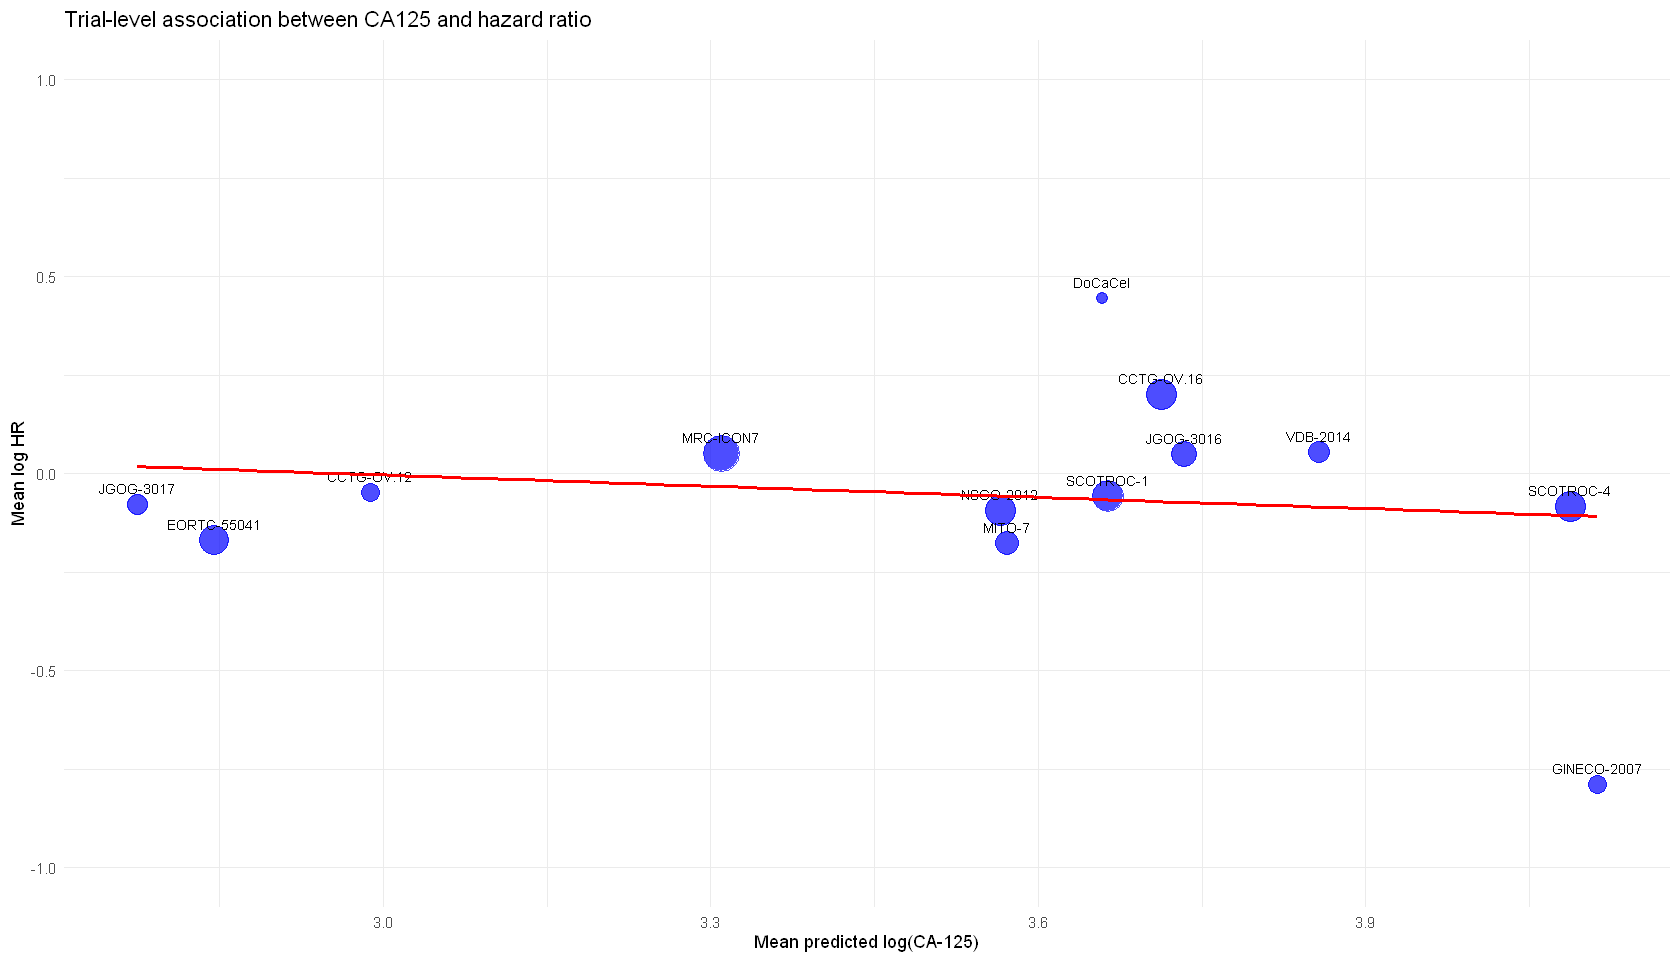

In [20]:

# =========================
# Plot
# =========================
options(repr.plot.width = 14, repr.plot.height = 8)

ggplot(trial_summary,
       aes(x = mean_log_ca125,
           y = log_hr)) +
  geom_point(aes(size = n_events), color = "blue", alpha = 0.7) +
  geom_text(aes(label = trialid), vjust = -1, size = 3) +
  geom_smooth(method = "lm", se = FALSE, color = "red") +
  scale_size(range = c(3, 10)) +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    x = "Mean predicted log(CA-125)",
    y = "Mean log HR",
    title = "Trial-level association between CA125 and hazard ratio"
  ) +
  ylim(-1, 1)

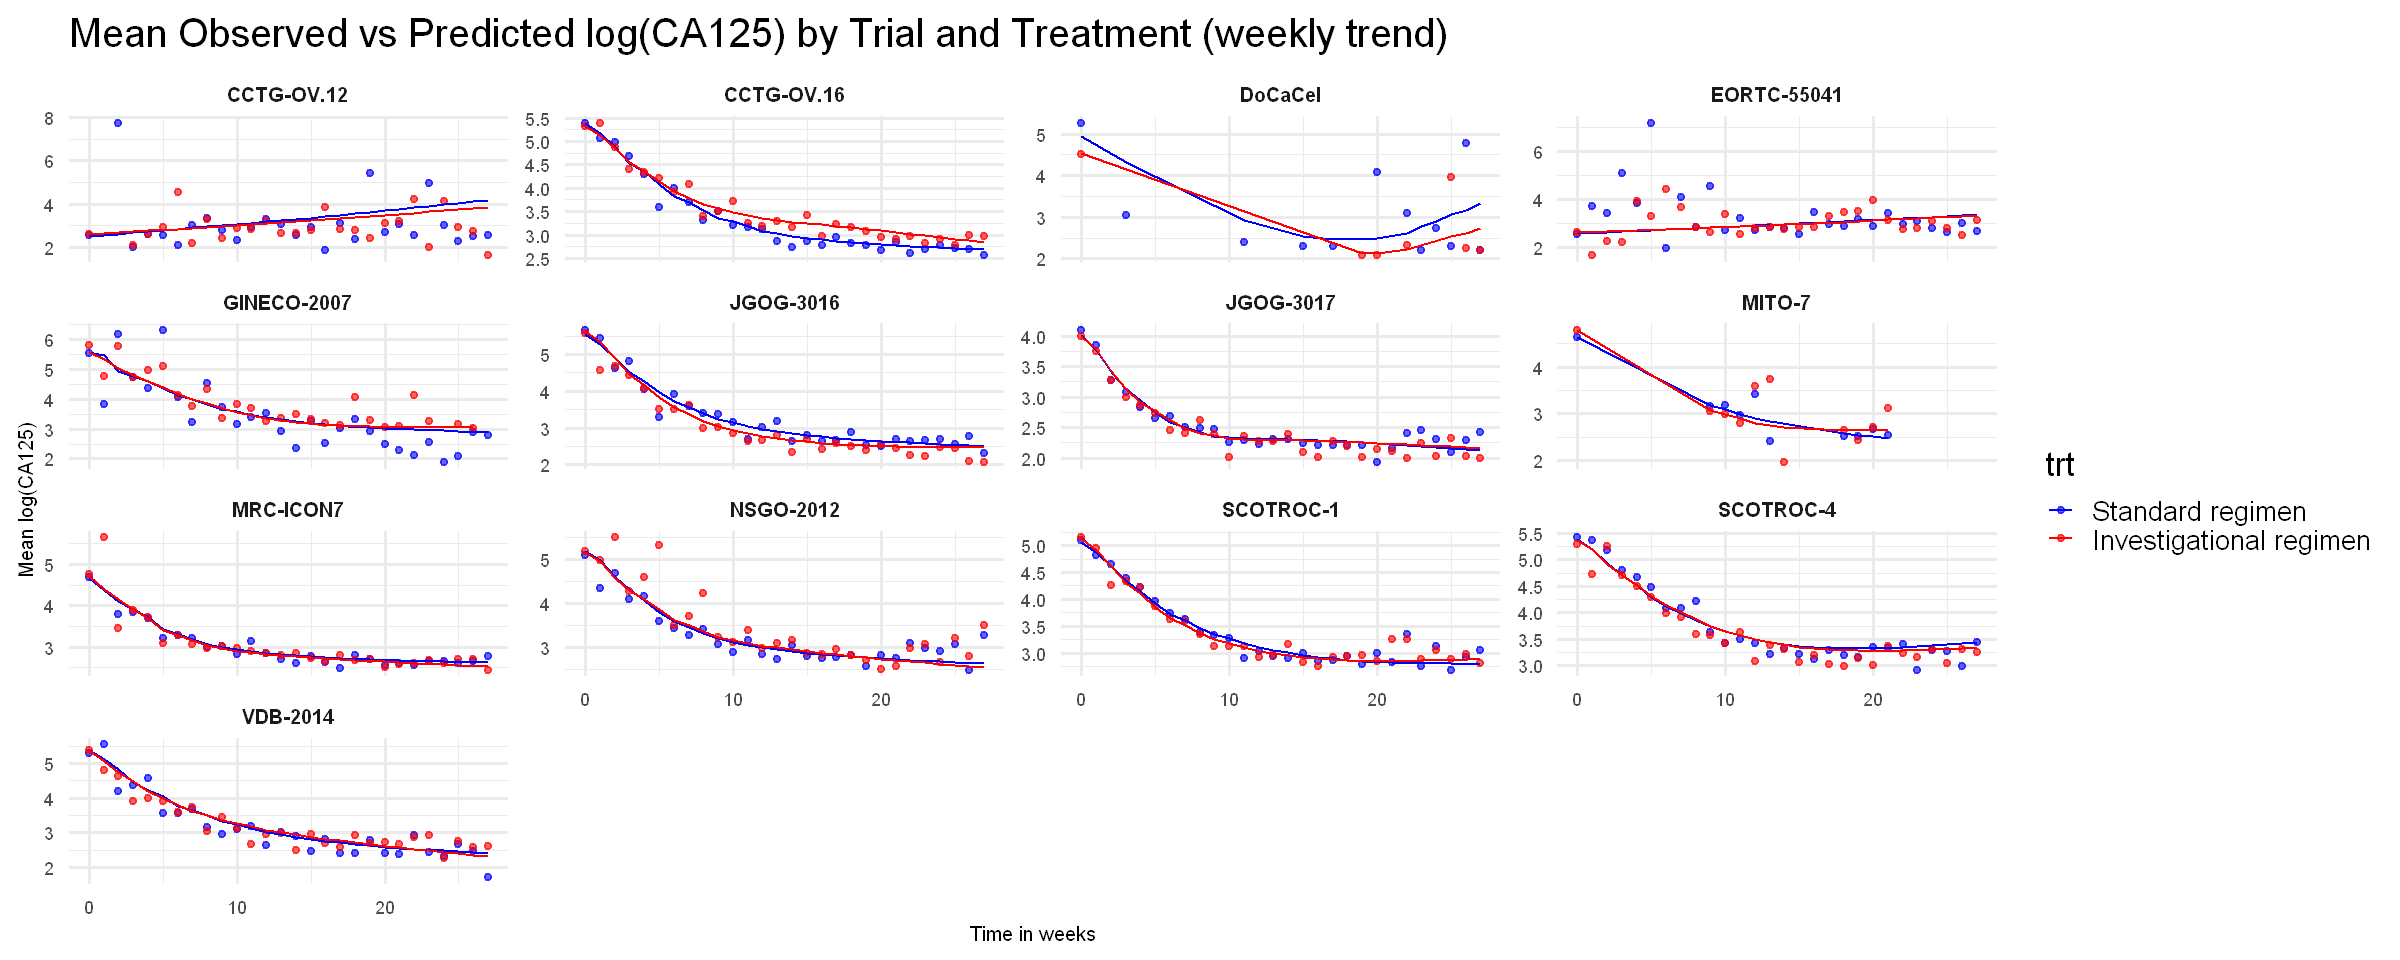

In [21]:
# Comparison between real trajectories and predicited ones
options(repr.plot.width = 20, repr.plot.height = 8)
trial_weekly_predictions %>%
  mutate(trt = factor(trt, levels = c(0, 1),
                        labels = c("Standard regimen", "Investigational regimen")))%>% 
  ggplot(aes(x = week, color = trt, group = trt)) +
  geom_point(aes(y = log_ca125_week),
             alpha = 0.6, size = 1.6) +
  geom_line(aes(y = log_ca125_pred_week),
            linewidth = 0.8) +
  facet_wrap(~ trialid, scales = "free_y") +
  scale_color_manual(values = c(
    "Standard regimen" = "blue",
    "Investigational regimen" = "red"
  )) +
  labs(
    title = "Mean Observed vs Predicted log(CA125) by Trial and Treatment (weekly trend)",
    x = "Time in weeks",
    y = "Mean log(CA125)"
  ) +
  theme_minimal(base_size=20) +
  theme(
    strip.text = element_text(size = 12, face = "bold"),
    axis.text = element_text(size = 11),
    axis.title = element_text(size = 12)
  )
 

**Compute $R^2_{trial}$**
- One joint model by trial then extract log(HR) associated with "trt_bin"
- Predict average log(CA-125) trajectory for treatment group and control group using joint model\
1) **Nadir:** $\Delta = min_t(\hat{Y}_{trt}) - min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta \Delta$\
              $\Delta_r = min_t(\hat{Y}_{trt})/min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta log(\Delta_r)$ 
2) **Time to nadir:** $\Delta_t = \text{time to }min_t(\hat{Y}_{trt}) - \text{time to }min_t(\hat{Y}_{ctrl})$, $log(HR) = \alpha + \beta \Delta_t$
3) **Difference of slopes:** $S_i=\frac{\hat{Y}(t_i) -\hat{Y}(t_i-1)}{t_i - t_i-1}$, $t_i \in \{30,60,90,120,150,180\}$, $log(HR) = \alpha + \beta (S_{i_{trt}}- S_{i_{ctrl}})$, $log(HR) = \alpha + \beta log(S_{i_{trt}}/ S_{i_{ctrl}})$
4) **Area between curves:** $AUC\approx \sum_{i=1}^{n-1} (t_{i+1} - t_i)\,\frac{(\hat{Y_{trt}}(t_i) -\hat{Y_{ctrl}}(t_i) )+ (\hat{Y}_{trt}(t_{i+1}) -\hat{Y}_{ctrl}(t_{i+1}))}{2}$, $log (HR)= \alpha + \beta AUC$
5) **Reduction from baseline:** $R_i=\frac{\hat{Y}(t_0) - \hat{y}(t_i)}{\hat{Y}(t_0)}$, $log (HR)= \alpha + \beta (R_{i_{trt}} - R_{i_{ctrl}})$,$log (HR)= \alpha + \beta log(R_{i_{trt}}/R_{i_{ctrl}})$
6) **Difference**: $log(HR)= \alpha +\beta (\hat{Y}(t_i)_{trt} - \hat{Y}(t_i)_{ctrl})$, $log(HR)= \alpha +\beta log(\hat{Y}(t_i)_{trt}/ \hat{Y}(t_i)_{ctrl})$




In [ ]:

summary_models <- list(
      nadir = lm(logHR ~ delta_nadir, data = trial_results, weights = n_events),
      time_nadir = lm(logHR ~ delta_time_nadir, data = trial_results, weights = n_events),
      auc = lm(logHR ~ delta_auc, data = trial_results, weights = n_events),
      beta_kelim = lm(logHR ~ beta_kelim, data = trial_results, weights = n_events),
      delta_kelim = lm(logHR ~ delta_kelim, data = trial_results, weights = n_events), 
      ratio_kelim = lm(logHR ~ ratio_kelim, data = trial_results, weights = n_events), 
      delta_pct1 = lm(logHR ~ pct_m1[1,]-pct_m2[2,], data = trial_results, weights = n_events),
      ratio_pct1 = lm(logHR ~ log(pct_m1[1]/pct_m2[2]), data = trial_results, weights = n_events),
      pct2= lm(logHR ~ pct_m2, data = trial_results, weights = n_events),
      pct3= lm(logHR ~ pct_m3, data = trial_results, weights = n_events),
      pct4= lm(logHR ~ pct_m4, data = trial_results, weights = n_events),
      pct5= lm(logHR ~ pct_m5, data = trial_results, weights = n_events),
      pct6= lm(logHR ~ pct_m6, data = trial_results, weights = n_events),
      henderson = lm(logHR ~ effect_trt_ca1251 + effect_trt_ca1252 + effect_trt_ca1253,data = trial_results, weights = n_events),
      slope1= lm(logHR ~ slope_m1 ,data = trial_results, weights = n_events),
      slope2= lm(logHR ~ slope_m2 ,data = trial_results, weights = n_events),
      slope3= lm(logHR ~ slope_m3 ,data = trial_results, weights = n_events),
      slope4= lm(logHR ~ slope_m4 ,data = trial_results, weights = n_events),
      slope5= lm(logHR ~ slope_m5 ,data = trial_results, weights = n_events),
      slope6= lm(logHR ~ slope_m6 ,data = trial_results, weights = n_events),
      abs1= lm(logHR ~ absolutediff_m1 ,data = trial_results, weights = n_events),
      abs2= lm(logHR ~ absolutediff_m2 ,data = trial_results, weights = n_events),
      abs3= lm(logHR ~ absolutediff_m3 ,data = trial_results, weights = n_events),
      abs4= lm(logHR ~ absolutediff_m4 ,data = trial_results, weights = n_events),
      abs5= lm(logHR ~ absolutediff_m5 ,data = trial_results, weights = n_events),
      abs6= lm(logHR ~ absolutediff_m6 ,data = trial_results, weights = n_events))
# -----------------------------
# extract R2 table
# -----------------------------
r2_table <- data.frame(
  model = names(summary_models),

  R2 = sapply(summary_models, function(m) summary(m)$r.squared),

  coeff = I(lapply(summary_models, function(m) {
    summary(m)$coefficients[, "Estimate"]
  })),

  pval = I(lapply(summary_models, function(m) {
    summary(m)$coefficients[, "Pr(>|t|)"]
  }))
)

In [ ]:
r2_table

In [ ]:
# #Weigthing by 1/var:
# summary_models2 <- list(
#       nadir = lm(logHR ~ delta_nadir, data = trial_results, weights = 1/(SE_logHR**2)),
#       time_nadir = lm(logHR ~ delta_time_nadir, data = trial_results, weights = 1/(SE_logHR**2)),
#       auc = lm(logHR ~ delta_auc, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct1 = lm(logHR ~ pct_m1, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct2= lm(logHR ~ pct_m2, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct3= lm(logHR ~ pct_m3, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct4= lm(logHR ~ pct_m4, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct5= lm(logHR ~ pct_m5, data = trial_results, weights = 1/(SE_logHR**2)),
#       pct6= lm(logHR ~ pct_m6, data = trial_results, weights = 1/(SE_logHR**2)),
#       henderson = lm(logHR ~ effect_trt_ca1251 + effect_trt_ca1252 + effect_trt_ca1253,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope1= lm(logHR ~ slope_m1 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope2= lm(logHR ~ slope_m2 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope3= lm(logHR ~ slope_m3 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope4= lm(logHR ~ slope_m4 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope5= lm(logHR ~ slope_m5 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       slope6= lm(logHR ~ slope_m6 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs1= lm(logHR ~ absolutediff_m1 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs2= lm(logHR ~ absolutediff_m2 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs3= lm(logHR ~ absolutediff_m3 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs4= lm(logHR ~ absolutediff_m4 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs5= lm(logHR ~ absolutediff_m5 ,data = trial_results, weights = 1/(SE_logHR**2)),
#       abs6= lm(logHR ~ absolutediff_m6 ,data = trial_results, weights = 1/(SE_logHR**2)))
# # -----------------------------
# # extract R2 table
# # -----------------------------
# r2_table2 <- data.frame(
#   model = names(summary_models2),

#   R2 = sapply(summary_models2, function(m) summary(m)$r.squared),

#   coeff = I(lapply(summary_models2, function(m) {
#     summary(m)$coefficients[, "Estimate"]
#   })),

#   pval = I(lapply(summary_models2, function(m) {
#     summary(m)$coefficients[, "Pr(>|t|)"]
#   }))
# )

In [ ]:
# cbind(r2_table[c("model","R2")],r2_table2["R2"])

In [ ]:
#Boostrap for r2 CI
set.seed(123)

B <- 2000
n <- nrow(trial_results)

boot_r2 <- matrix(NA, nrow = B, ncol = 23)
colnames(boot_r2) <- c("nadir","time_nadir","auc","beta_kelim", "delta_kelim","pct1","pct2","pct3", "pct4", "pct5","pct6",
                       "slope1","slope2","slope3","slope4", "slope5","slope6",
                       "abs1","abs2","abs3","abs4","abs5","abs6")

for (b in 1:B) {

  idx <- sample(1:n, size = n, replace = TRUE)
  data_b <- trial_results[idx, ]

  boot_r2[b, ] <- get_r2_models(data=data_b)
}
boot_summary1 <- data.frame(
  model = colnames(boot_r2),

  R2 = apply(boot_r2, 2, mean, na.rm = TRUE),

  R2_low = apply(boot_r2, 2, quantile, 0.025, na.rm = TRUE),

  R2_high = apply(boot_r2, 2, quantile, 0.975, na.rm = TRUE)
)

boot_summary1

In [ ]:
ca125_all_6 %>%mutate(week_ca125=round(time_ca125/7))%>%
  group_by(trialid, trt, week_ca125) %>%
  summarise(mean_ca125 = mean(log_ca125, na.rm = TRUE), .groups = "drop") %>%
  group_by(trialid, trt) %>%
  summarise(min_mean_ca125 = min(mean_ca125, na.rm = TRUE), .groups = "drop")

Leave-one-trial-out

In [ ]:
# ----------------------------------
# formulas for all summary models
# ----------------------------------

summary_formulas <- list(
  nadir = logHR ~ delta_nadir,
  time_nadir = logHR ~ delta_time_nadir,
  auc = logHR ~ delta_auc,
  beta_kelim = logHR ~ beta_kelim,
  delta_kelim = logHR ~ delta_kelim,

  pct1 = logHR ~ pct_m1,
  pct2 = logHR ~ pct_m2,
  pct3 = logHR ~ pct_m3,
  pct4 = logHR ~ pct_m4,
  pct5 = logHR ~ pct_m5,
  pct6 = logHR ~ pct_m6,

  henderson = logHR ~ effect_trt_ca1251 +
                      effect_trt_ca1252 +
                      effect_trt_ca1253,

  slope1 = logHR ~ slope_m1,
  slope2 = logHR ~ slope_m2,
  slope3 = logHR ~ slope_m3,
  slope4 = logHR ~ slope_m4,
  slope5 = logHR ~ slope_m5,
  slope6 = logHR ~ slope_m6,

  abs1 = logHR ~ absolutediff_m1,
  abs2 = logHR ~ absolutediff_m2,
  abs3 = logHR ~ absolutediff_m3,
  abs4 = logHR ~ absolutediff_m4,
  abs5 = logHR ~ absolutediff_m5,
  abs6 = logHR ~ absolutediff_m6
)

# ----------------------------------
# leave-one-study-out
# ----------------------------------

B <- 1000

loso_boot_results <- list()

for(trial_out in unique(trial_results$trialid)) {

  cat("Leaving out:", trial_out, "\n")

  df_loso <- subset(
    trial_results,
    trialid != trial_out
  )

  model_results <- lapply(names(summary_formulas), function(model_name){

    r2_boot <- replicate(B, {

      idx <- sample(
        seq_len(nrow(df_loso)),
        size = nrow(df_loso),
        replace = TRUE
      )

      boot_df <- df_loso[idx, ]

      fit <- lm(
        summary_formulas[[model_name]],
        data = boot_df,
        weights = n
      )

      suppressWarnings(summary(fit)$r.squared)
    })

    data.frame(
      left_out_trial = trial_out,
      summary = model_name,
      R2 = mean(r2_boot),
      CI_low = quantile(r2_boot, 0.025),
      CI_high = quantile(r2_boot, 0.975)
    )
  })

  loso_boot_results[[trial_out]] <- bind_rows(model_results)
}

loso_boot_r2 <- bind_rows(loso_boot_results)

In [ ]:
plot_df <- loso_boot_r2 %>%
  filter(summary %in% c(
    "pct3",
    "abs3",
    "slope3",
    "pct6",
    "abs6",
    "slope6",
    "delta_kelim"
  )) %>%
  mutate(
    summary = factor(
      summary,
      levels = c(
        "pct3",
        "pct6",
        "abs3",
        "abs6",
        "slope3",
        "slope6",
        "delta_kelim"
      ),
      labels = c(
        "Reduction from baseline (3 months)",
        "Reduction from baseline (6 months)",
        "Absolute difference (3 months)",
        "Absolute difference (6 months)",
        "Difference in slopes (3 months)",
        "Difference in slopes (6 months)",
        "KELIM (3 months)"
      )
    )
  )

ggplot(
  plot_df,
  aes(
    x = reorder(left_out_trial, R2),
    y = R2
  )
) +
  geom_segment(
    aes(
      xend = left_out_trial,
      y = 0,
      yend = R2
    )
  ) +
  geom_point(size = 2.5) +
  coord_flip() +
  facet_wrap(~summary, ncol = 3, scales = "fixed") +
  labs(
    x = "Trial omitted",
    y = expression(R^2),
    title = "Leave-one-study-out sensitivity analysis"
  ) +
  theme_bw() +
  theme(
    strip.text = element_text(face = "bold"),
    axis.text.y = element_text(size = 7)
  )

**No maintenance trials**

In [ ]:
#Boostrap for r2 CI
set.seed(123)

B <- 2000
n <- nrow(trial_results[-c(1,3,4,9), ])

boot_r2 <- matrix(NA, nrow = B, ncol = 23)
colnames(boot_r2) <- c("nadir","time_nadir","auc","beta_kelim", "delta_kelim","pct1","pct2","pct3", "pct4", "pct5","pct6",
                       "slope1","slope2","slope3","slope4", "slope5","slope6",
                       "abs1","abs2","abs3","abs4","abs5","abs6")

for (b in 1:B) {

  idx <- sample(1:n, size = n, replace = TRUE)
  data_b <- trial_results[-c(1,3,4,9), ][idx, ]

  boot_r2[b, ] <- get_r2_models(data=data_b)
}
boot_summary2 <- data.frame(
  model = colnames(boot_r2),

  R2 = apply(boot_r2, 2, mean, na.rm = TRUE),

  R2_low = apply(boot_r2, 2, quantile, 0.025, na.rm = TRUE),

  R2_high = apply(boot_r2, 2, quantile, 0.975, na.rm = TRUE)
)

boot_summary2

**Same trials as KELIM ones**

In [ ]:
#Boostrap for r2 CI
set.seed(123)

B <- 2000
n <- nrow(trial_results[-c(1,3,4,8,13), ])

boot_r2 <- matrix(NA, nrow = B, ncol = 23)
colnames(boot_r2) <- c("nadir","time_nadir","auc","beta_kelim", "delta_kelim","pct1","pct2","pct3", "pct4", "pct5","pct6",
                       "slope1","slope2","slope3","slope4", "slope5","slope6",
                       "abs1","abs2","abs3","abs4","abs5","abs6")

for (b in 1:B) {

  idx <- sample(1:n, size = n, replace = TRUE)
  data_b <- trial_results[-c(1,3,4,8,13), ][idx, ]

  boot_r2[b, ] <- get_r2_models(data=data_b)
}
boot_summary3 <- data.frame(
  model = colnames(boot_r2),

  R2 = apply(boot_r2, 2, mean, na.rm = TRUE),

  R2_low = apply(boot_r2, 2, quantile, 0.025, na.rm = TRUE),

  R2_high = apply(boot_r2, 2, quantile, 0.975, na.rm = TRUE)
)

boot_summary3

In [ ]:
ggplot(rbind(
  boot_summary1 %>% rownames_to_column("summary") %>% filter(!summary %in% c("beta_kelim", "delta_kelim"))%>% mutate(dataset = "All 13 trials"),
  boot_summary3 %>% rownames_to_column("summary") %>% filter(!summary %in% c("beta_kelim", "delta_kelim"))%>% mutate(dataset = "Only KELIM trials (8)")
),
       aes(x = summary,
           y = R2,
           color = dataset,
           group = dataset)) +
  geom_line(linewidth = 1) +
  geom_point(size = 2) +
  theme(
    axis.title = element_text(size = 14),   
    axis.text = element_text(size = 12),    
    legend.title = element_text(size = 14),
    legend.text = element_text(size = 13),
    plot.title = element_text(size = 18)
  ) +
  labs(x = "Summary",
       y = expression(R^2),
       color = "")

# Survival-continuous surrogacy evaluation for KELIM : copula model

In [ ]:
kelim_data <- kelim %>%
  filter(!is.na(KELIM_continuous),!is.na(PFS_time))%>% 
  mutate(trialid_num = as.numeric(as.factor(trial_name)), 
         id_num=as.numeric(as.factor(id)),
         pfs_time_d=as.numeric(PFS_time*365.2425 ),
         pfs_statut=factor(ifelse(PFS_status=='Yes', 1, 0), levels=c(0,1))
         ) %>%
  mutate(
    id_num = unname(id_num),
    trt_bin = unname(trt_bin),
    trialid_num = unname(trialid_num),
    pfs_time_d = unname(pfs_time_d),
    pfs_statut = unname(pfs_statut),
    KELIM_continuous = unname(KELIM_continuous)
  )
kelim_data$trt_bin <- as.numeric(as.character(kelim_data$trt_bin))
kelim_data$pfs_statut <- as.numeric(as.character(kelim_data$pfs_statut))
print(paste0(c("Number of measurements with KELIM data:", nrow(kelim_data), 
"\nNumber of patients with KELIM data:", length(unique(kelim_data$id)))))

[1] "Number of measurements with KELIM data:"
[2] "5883"                                   
[3] "\nNumber of patients with KELIM data:"  
[4] "5883"                                   


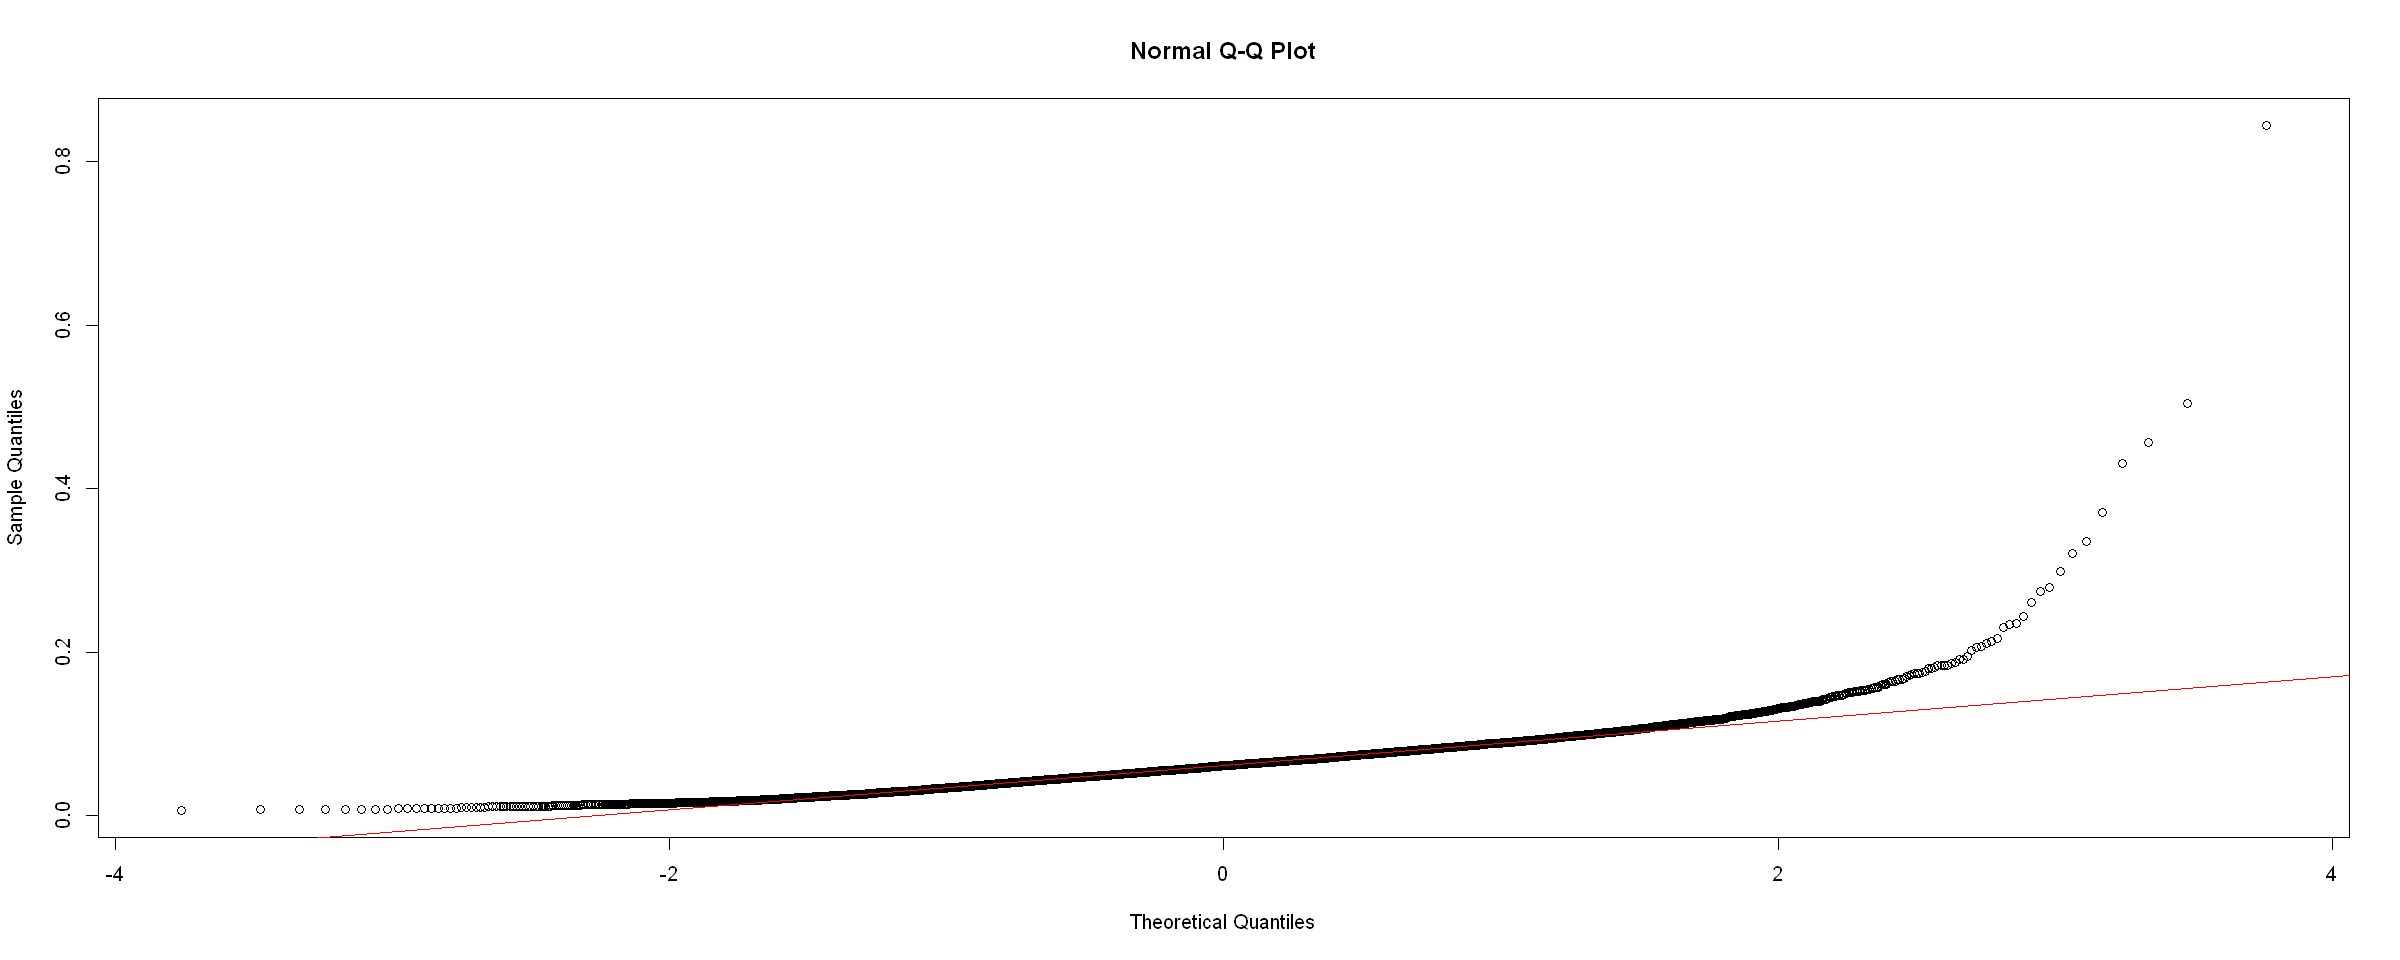

In [ ]:
qqnorm(kelim$KELIM_continuous)
qqline(kelim$KELIM_continuous, col="red")

In [ ]:
survcont_plackett_w<-MetaAnalyticSurvCont(
  data=kelim_data,
  true=pfs_time_d,
  trueind=pfs_statut,
  surrog=KELIM_continuous,
  trt=trt_bin,
  center=trialid_num,
  trial=trialid_num,
  patientid=id_num,
  copula="Plackett",
  adjustment="weighted"
)
survcont_plackett_w$nlm.output$code

Fitting the model with Plackett copula...



[1] 2

In [ ]:
print(survcont_plackett_w)

Surrogacy measures with 95% confidence interval 

Individual level surrogacy:  

Spearmans rho :  0.4565 [ 0.4335 ; 0.4796 ] 

Trial level surrogacy:  

R Square:  0.4593 [ 0.0000 ; 1.0000 ] 

Estimated treatment effects on surrogate (surro_est) and survival (surv_est) endpoint: 

 center     surv_est    surv_se    surro_est    surro_se sample_size
      1  0.002721574 0.08070452 -0.003107647 0.001908738         699
      2  0.013467732 0.21192123 -0.007736377 0.005919058          96
      3 -0.278172919 0.10949339  0.007061525 0.003942289         510
      4  0.063548996 0.15913101  0.003677174 0.003196164         554
      5  0.030120031 0.06240129  0.000396086 0.001369127        1442
      6  0.112155822 0.08595292 -0.003835926 0.002245621         680
      7 -0.011138718 0.07830125  0.002831010 0.002073187        1019
      8 -0.049708687 0.07900071  0.001661804 0.001825067         883


`geom_smooth()` using formula = 'y ~ x'


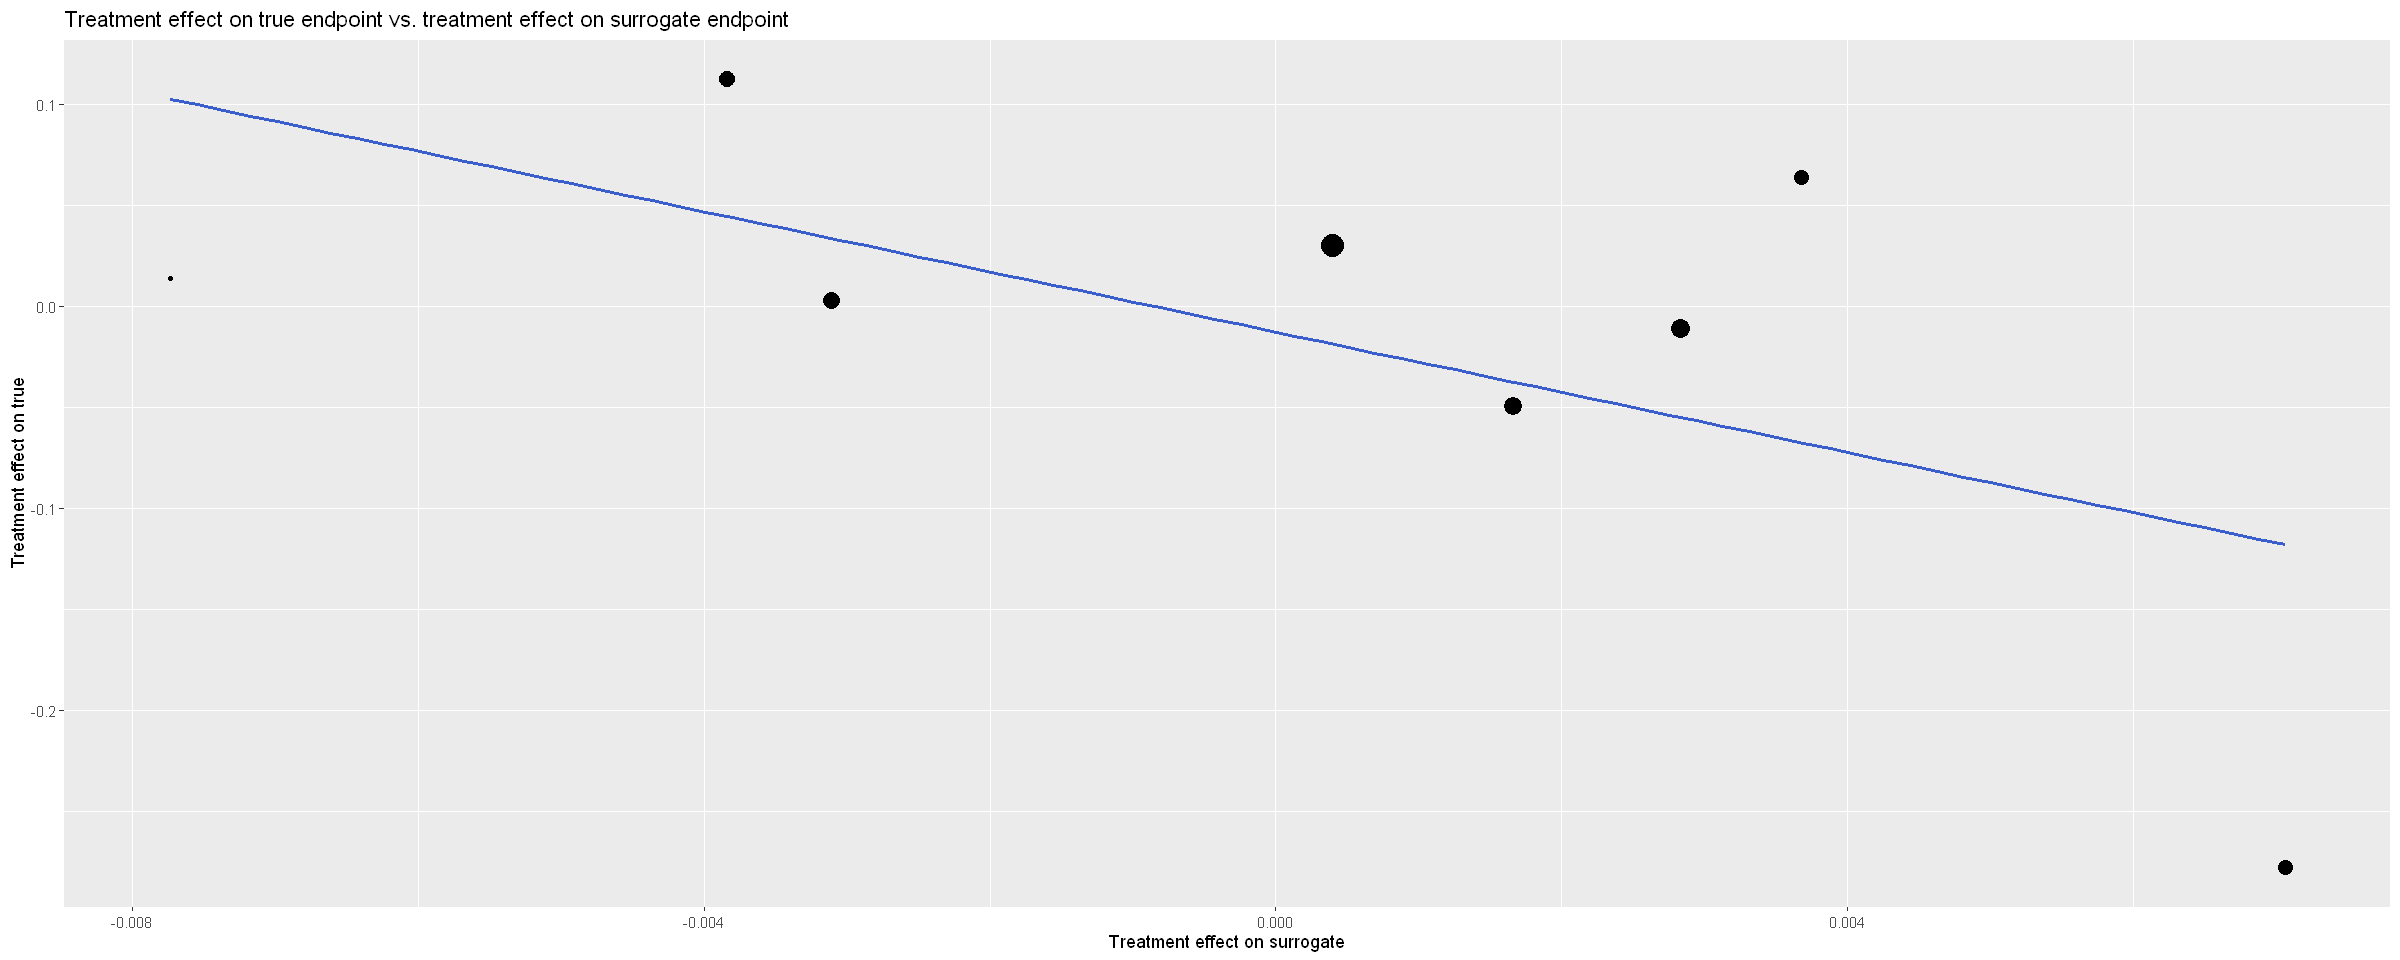

In [ ]:
plot(survcont_plackett_w)

In [ ]:
# survcont_clayton<-MetaAnalyticSurvCont(
#   data=kelim_data,
#   true=pfs_time_d,
#   trueind=pfs_statut,
#   surrog=KELIM_continuous,
#   trt=trt_bin,
#   center=trialid_num,
#   trial=trialid_num,
#   patientid=id_num,
#   copula="Clayton",
#   adjustment="adjusted"
# )
# survcont_clayton$nlm.output$code

# survcont_hougaard<-MetaAnalyticSurvCont(
#   data=kelim_data,
#   true=pfs_time_d,
#   trueind=pfs_statut,
#   surrog=KELIM_continuous,
#   trt=trt_bin,
#   center=trialid_num,
#   trial=trialid_num,
#   patientid=id_num,
#   copula="Hougaard",
#   adjustment="adjusted"
# )
# survcont_hougaard$nlm.output$code


survcont_plackett_a<-MetaAnalyticSurvCont(
  data=kelim_data,
  true=pfs_time_d,
  trueind=pfs_statut,
  surrog=KELIM_continuous,
  trt=trt_bin,
  center=trialid_num,
  trial=trialid_num,
  patientid=id_num,
  copula="Plackett",
  adjustment="adjusted"
)
survcont_plackett_a$nlm.output$code

In [ ]:
print(survcont_plackett_a)

In [ ]:
plot(survcont_plackett_a)

In [ ]:
pak::pak("DenisRustand/INLAjoint")

 

→ Package library at C:\Users\atanoh\AppData\Local\Programs\R\R-4.6.1\library.

ℹ No downloads are needed

✔ 1 pkg + 24 deps: kept 21 [3.6s]



In [ ]:
library(INLAjoint)

In [ ]:
# # One row per patient
# patients <- ca125_all_6 %>%
#   distinct(id, trialid, trt_bin, pfs_statut)

# # Trial sizes
# trial_sizes <- patients %>%
#   count(trialid, name = "n_trial")

# # Trials with fewer than 115 patients
# small_trials <- trial_sizes %>%
#   filter(n_trial < 115) %>%
#   pull(trialid)

# # Keep all patients from small trials
# keep_small <- patients %>%
#   filter(trialid %in% small_trials)

# # Patients from larger trials
# large_patients <- patients %>%
#   filter(!trialid %in% small_trials)

# # Number of additional patients needed
# n_target <- 1300
# n_to_sample <- n_target - nrow(keep_small)

# # Sampling fraction among large trials
# sampling_fraction <- n_to_sample / nrow(large_patients)

# # Stratified sampling by trial and PFS status
# set.seed(123)

# sampled_large <- large_patients %>%
#   group_by(trialid, pfs_statut) %>%
#   slice_sample(prop = sampling_fraction) %>%
#   ungroup()

# # Final patient sample
# sample_patients <- bind_rows(
#   keep_small,
#   sampled_large
# ) %>%
#   distinct(id, .keep_all = TRUE)

# # Recover all longitudinal observations
# ca125_subset <- ca125_all_6 %>%
#   semi_join(sample_patients, by = "id")

In [ ]:
#Model input
ca125_all_6<-ca125_all_6%>% arrange(id_num, time_ca125)
ca125_all_6_surv<-ca125_all_6[!duplicated(ca125_all_6$id),]
f1 <- function(x) predict(ns_basis, x)[,1]
f2 <- function(x) predict(ns_basis, x)[,2]
f3 <- function(x) predict(ns_basis, x)[,3]
ca125_all_6<-ca125_all_6%>% arrange(id_num, time_ca125)
n_trials<- length(unique(ca125_all_6$trialid_num))

In [ ]:
#model setup
formLong <- log_ca125 ~ f1(time_ca125) + f2(time_ca125) + f3(time_ca125) + trt_bin:f1(time_ca125)+ trt_bin:f2(time_ca125)+ trt_bin:f3(time_ca125)+ (1 + f1(time_ca125) + f2(time_ca125)+ f3(time_ca125) |id_num)#+(trt_bin:f1(time_ca125)+ trt_bin:f2(time_ca125)+ trt_bin:f3(time_ca125)|trialid_num) #DR cette partie de la formule était ignorée
formSurv <- INLA::inla.surv(pfs_time_d, pfs_statut) ~ trt_bin + (1|trialid_num)
model_setup <- joint(
  formSurv  = list(formSurv),
  formLong  = list(formLong),
  dataSurv  = as.data.frame(ca125_subset_surv),
  dataLong  = as.data.frame(ca125_subset),
  id        = "id_num",
  timeVar   = "time_ca125",
  family    = "gaussian",
  basRisk   = "rw2", 
  NbasRisk = 50,
  assoc     = "SRE_ind",
  control   = list(int.strategy = "eb", verbose=TRUE),
  run=FALSE, 
)
formLong_trial <- log_ca125 ~ trt_bin + f1(time_ca125) + f2(time_ca125) + f3(time_ca125) + trt_bin:f1(time_ca125)+ trt_bin:f2(time_ca125)+ trt_bin:f3(time_ca125)+(1 + f1(time_ca125)+ f2(time_ca125)+ f3(time_ca125)|trialid_num)
model_setup_trial <- joint(
  formSurv  = list(formSurv),
  formLong  = list(formLong_trial),
  dataSurv  = as.data.frame(ca125_subset_surv),
  dataLong  = as.data.frame(ca125_subset),
  id        = "trialid_num",
  timeVar   = "time_ca125",
  family    = "gaussian",
  basRisk   = "rw2", 
  NbasRisk = 50,
  assoc     = "SRE_ind",
  corRE= FALSE, 
  control   = list(int.strategy = "eb", verbose=TRUE), 
  run=FALSE,
)


In [ ]:
# weight trial level random effect in survival with trt
model_setup$.args$data$IDIntercept_S1 <- model_setup_trial$.args$data$IDIntercept_S1
model_setup$.args$data$WIntercept_S1 <- model_setup_trial$.args$data$WIntercept_S1*model_setup_trial$.args$data$trt_bin_S1

#DR: Treatment * splines random effects id
model_setup$.args$data$IDTrial0 <- model_setup_trial$.args$data$IDIntercept_L1
model_setup$.args$data$IDTrial1 <- model_setup_trial$.args$data$IDf1time_ca125_L1
model_setup$.args$data$IDTrial2 <- model_setup_trial$.args$data$IDf2time_ca125_L1
model_setup$.args$data$IDTrial3 <- model_setup_trial$.args$data$IDf3time_ca125_L1

# Treatment * splines random effects weights
model_setup$.args$data$WTrial0 <- model_setup_trial$.args$data$WIntercept_L1 # intercept general niveau trial
model_setup$.args$data$WTrial1 <- model_setup_trial$.args$data$Wf1time_ca125_L1 * model_setup_trial$.args$data$trt_bin_L1
model_setup$.args$data$WTrial2 <- model_setup_trial$.args$data$Wf2time_ca125_L1 * model_setup_trial$.args$data$trt_bin_L1
model_setup$.args$data$WTrial3 <- model_setup_trial$.args$data$Wf3time_ca125_L1 * model_setup_trial$.args$data$trt_bin_L1

# Share and scale the trial level random effects in survival
model_setup$.args$data$IDTrial0_SRE <- model_setup_trial$.args$data$SRE_Intercept_L1_S1
model_setup$.args$data$IDTrial1_SRE <- model_setup_trial$.args$data$SRE_f1time_ca125_L1_S1
model_setup$.args$data$IDTrial2_SRE <- model_setup_trial$.args$data$SRE_f2time_ca125_L1_S1
model_setup$.args$data$IDTrial3_SRE <- model_setup_trial$.args$data$SRE_f3time_ca125_L1_S1

# Priors
prior_prec <- list(prior = "loggamma",param = c(1.5, 0.5))

# Set environnement
environment(model_setup$.args$formula)$IDTrial0_SRE <- model_setup$.args$data$IDTrial0_SRE
environment(model_setup$.args$formula)$IDTrial1_SRE <- model_setup$.args$data$IDTrial1_SRE
environment(model_setup$.args$formula)$IDTrial2_SRE <- model_setup$.args$data$IDTrial2_SRE
environment(model_setup$.args$formula)$IDTrial3_SRE <- model_setup$.args$data$IDTrial3_SRE
environment(model_setup$.args$formula)$IDTrial0 <- model_setup$.args$data$IDTrial0
environment(model_setup$.args$formula)$IDTrial1 <- model_setup$.args$data$IDTrial1
environment(model_setup$.args$formula)$IDTrial2 <- model_setup$.args$data$IDTrial2
environment(model_setup$.args$formula)$IDTrial3 <- model_setup$.args$data$IDTrial3
environment(model_setup$.args$formula)$WTrial0 <- model_setup$.args$data$WTrial0
environment(model_setup$.args$formula)$WTrial1 <- model_setup$.args$data$WTrial1
environment(model_setup$.args$formula)$WTrial2 <- model_setup$.args$data$WTrial2
environment(model_setup$.args$formula)$WTrial3 <- model_setup$.args$data$WTrial3
environment(model_setup$.args$formula)$n_trials <- n_trials
environment(model_setup$.args$formula)$prior_prec <- prior_prec

# Add the trial-level random effects to the formula
model_setup$.args$formula <- update(
  model_setup$.args$formula,
  ~ . + f(IDTrial0, WTrial0, model = "iid", n = n_trials, constr = FALSE, hyper = list(theta = list(prior = "loggamma",param = c(1.5, 0.5),hyperid = 90001))) +
    f(IDTrial1, WTrial1, model = "iid", n = n_trials, constr = FALSE, hyper = list(prec = list(prior = "loggamma",param = c(1.5, 0.5),hyperid = 90002))) +
    f(IDTrial2, WTrial2, model = "iid", n = n_trials, constr = FALSE, hyper = list(prec = list(prior = "loggamma",param = c(1.5, 0.5),hyperid = 90003))) +
    f(IDTrial3, WTrial3, model = "iid", n = n_trials, constr = FALSE, hyper = list(prec = list(prior = "loggamma",param = c(1.5, 0.5),hyperid = 90004))) + 
    f(IDTrial0_SRE, copy = "IDTrial0", hyper = list(beta = list(fixed = FALSE, param = c(0, 1), initial = 0.1,hyperid = 90011))) + 
    f(IDTrial1_SRE, copy = "IDTrial1", hyper = list(beta = list(fixed = FALSE, param = c(0, 1), initial = 0.1,hyperid = 90012))) + 
    f(IDTrial2_SRE, copy = "IDTrial2", hyper = list(beta = list(fixed = FALSE, param = c(0, 1), initial = 0.1,hyperid = 90013))) + 
    f(IDTrial3_SRE, copy = "IDTrial3", hyper = list(beta = list(fixed = FALSE, param = c(0, 1),  initial = 0.1,hyperid = 90014)))
)

# run the modela
model_setup$.args$verbose <- TRUE
INLA::inla.setOption(safe = FALSE)
INLA::inla.setOption(keep = TRUE)
model_fit <- joint.run(model_setup, slientMode=FALSE)
# saveRDS(model_fit, file = "jointed_inla_pfs.rds")

# # model
# model_fit <- readRDS("jointed_inla_pfs.rds")


In [ ]:

# relancer, puis :
dir(INLA::inla.get.inlaEnv())  # ou chercher le dossier temporaire "Model...\ mentionné en verbose

In [ ]:
saveRDS(model_fit, file = "jointed_inla.rds")

In [ ]:
model_fit <- readRDS("jointed_inla_pfs.rds")

In [ ]:
#print summary
print(summary(model_fit, sdcor=TRUE)) 

Longitudinal outcome (gaussian)
                           mean     sd 0.025quant 0.5quant 0.975quant
Intercept_L1             4.4259 0.0645     4.2995   4.4259     4.5523
f1time_ca125_L1         -1.3237 0.0228    -1.3683  -1.3237    -1.2791
f2time_ca125_L1         -2.6092 0.0317    -2.6713  -2.6092    -2.5471
f3time_ca125_L1         -1.0124 0.0221    -1.0558  -1.0124    -0.9690
f1time_ca125:trt_bin_L1 -0.0985 0.0683    -0.2325  -0.0985     0.0354
f2time_ca125:trt_bin_L1  0.0246 0.1177    -0.2061   0.0246     0.2553
f3time_ca125:trt_bin_L1 -0.0628 0.0679    -0.1958  -0.0628     0.0703
Res. err. (sd)           0.3313 0.0346     0.2689   0.3295     0.4047

Random effects standard deviation / correlation (L1)
                                   mean     sd 0.025quant 0.5quant 0.975quant
Intercept_L1                     1.8907 0.8380     1.0368   1.6591     4.0447
f1time_ca125_L1                  1.4789 0.3872     0.9358   1.4036     2.4178
f2time_ca125_L1                  2.2259 0.7174    

In [ ]:
model_fit$summary.random$IDTrial1 # effet aleatoire traitement sur premiere spline niveau trial
model_fit$summary.random$IDTrial2 # pareil spline 2
model_fit$summary.random$IDTrial3 # spline 3

ID,mean,sd,0.025quant,0.5quant,0.975quant,mode,kld
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.61471139,0.10651905,0.405937880,0.61471139,0.8234849,0.61471139,0
2,0.09276792,0.06982428,-0.044085159,0.09276792,0.2296210,0.09276792,0
3,0.04892415,0.19635627,-0.335927076,0.04892415,0.4337754,0.04892415,0
4,-0.52860925,0.09961554,-0.723852114,-0.52860925,-0.3333664,-0.52860925,0
5,-0.04480797,0.11383317,-0.267916873,-0.04480797,0.1783009,-0.04480797,0
6,-0.42885248,0.07623780,-0.578275822,-0.42885248,-0.2794291,-0.42885248,0
7,-0.29437027,0.07401104,-0.439429253,-0.29437027,-0.1493113,-0.29437027,0
8,0.20619338,0.16413611,-0.115507492,0.20619338,0.5278942,0.20619338,0
9,0.08389492,0.06759094,-0.048580892,0.08389492,0.2163707,0.08389492,0


ID,mean,sd,0.025quant,0.5quant,0.975quant,mode,kld
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1.81612836,0.1665394,1.48971712,1.81612836,2.14253961,1.81612836,0
2,-0.32500366,0.1259046,-0.57177224,-0.32500366,-0.07823509,-0.32500366,0
3,0.01609449,0.3347529,-0.64000923,0.01609449,0.67219822,0.01609449,0
4,1.94175158,0.1459045,1.65578395,1.94175158,2.22771921,1.94175158,0
5,0.01311749,0.1877625,-0.35489032,0.01311749,0.38112531,0.01311749,0
6,-1.14036252,0.1320408,-1.39915763,-1.14036252,-0.88156740,-1.14036252,0
7,-0.85690647,0.1302962,-1.11228234,-0.85690647,-0.60153060,-0.85690647,0
8,-0.02542838,0.1589001,-0.33686679,-0.02542838,0.28601003,-0.02542838,0
9,-0.32712874,0.1198486,-0.56202776,-0.32712874,-0.09222973,-0.32712874,0


ID,mean,sd,0.025quant,0.5quant,0.975quant,mode,kld
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.62782679,0.11096027,0.41034867,0.62782679,0.845304918,0.62782679,0
2,-0.15508342,0.07477960,-0.30164874,-0.15508342,-0.008518098,-0.15508342,0
3,-0.01602290,0.19866276,-0.40539476,-0.01602290,0.373348956,-0.01602290,0
4,0.07177678,0.08126570,-0.08750106,0.07177678,0.231054612,0.07177678,0
5,-0.01496005,0.12912952,-0.26804926,-0.01496005,0.238129154,-0.01496005,0
6,-0.20095300,0.08216263,-0.36198880,-0.20095300,-0.039917208,-0.20095300,0
7,-0.26323881,0.07902518,-0.41812532,-0.26323881,-0.108352305,-0.26323881,0
8,0.06366111,0.12383573,-0.17905245,0.06366111,0.306374671,0.06366111,0
9,-0.01362117,0.07027003,-0.15134790,-0.01362117,0.124105560,-0.01362117,0


In [ ]:
N_sample <- 3 # 3 pour l'exemple mais il en faut au moins 1000 en pratique
SMP <- inla.posterior.sample(N_sample, model_fit)
all_rownames <- rownames(SMP[[1]]$latent)
CT <- model_fit$misc$configs$contents # structure des samples

tags <- c("f1time_ca125.X.trt_bin_L1", "f2time_ca125.X.trt_bin_L1", "f3time_ca125.X.trt_bin_L1",
             "IDTrial1", "IDTrial2", "IDTrial3")
idx_list <- setNames(lapply(match(tags, CT$tag), function(i) {seq(CT$start[i], length.out = CT$length[i])}), tags)
sapply(SMP, function(x) x$latent[idx_list$f1time_ca125.X.trt_bin_L1, 1]) # samples trt:spline 1 fixed effect
sapply(SMP, function(x) x$latent[idx_list$f2time_ca125.X.trt_bin_L1, 1]) # samples trt:spline 2 fixed effect
sapply(SMP, function(x) x$latent[idx_list$f3time_ca125.X.trt_bin_L1, 1]) # samples trt:spline 3 fixed effect
sapply(SMP, function(x) x$latent[idx_list$IDTrial1, 1]) # samples trt:spline 1 random effect
sapply(SMP, function(x) x$latent[idx_list$IDTrial2, 1]) # samples trt:spline 2 random effect
sapply(SMP, function(x) x$latent[idx_list$IDTrial3, 1]) # samples trt:spline 3 random effect

In [ ]:
INLA::inla.getOption("num.threads")

[1] "10:1"

In [ ]:
parallel::detectCores()

[1] 12

In [ ]:
INLA::inla.getOption()

$inla.arg
NULL

$num.threads
[1] "10:1"

$blas.num.threads
[1] 0

$smtp
[1] "default"

$safe
[1] TRUE

$keep
[1] FALSE

$verbose
[1] FALSE

$save.memory
[1] FALSE

$internal.opt
[1] TRUE

$working.directory
NULL

$silent
[1] TRUE

$debug
[1] FALSE

$show.warning.graph.file
[1] TRUE

$scale.model.default
[1] FALSE

$short.summary
[1] FALSE

$inla.timeout
[1] 0

$inla.mode
[1] "compact"

$malloc.lib
[1] "default"

$fmesher.evolution
[1] 2

$fmesher.evolution.warn
[1] TRUE

$fmesher.evolution.verbosity
[1] "default"

$INLAjoint.features
[1] FALSE

$numa
[1] FALSE

$disable.values.warning
[1] FALSE

$inla.call
[1] "C:/Users/atanoh/AppData/Local/Programs/R/R-4.6.1/library/INLA/bin/windows/64bit/inla.exe"

In [ ]:
set.seed(123)

N_sample <- 1000

SMP <- INLA::inla.posterior.sample(
  N_sample,
  model_fit
)

CT <- model_fit$misc$configs$contents

In [ ]:
tags <- c(
  # fixed effects longitudinal
  "Intercept_L1",
  "f1time_ca125_L1",
  "f2time_ca125_L1",
  "f3time_ca125_L1",

  # fixed treatment × spline effects
  "f1time_ca125.X.trt_bin_L1",
  "f2time_ca125.X.trt_bin_L1",
  "f3time_ca125.X.trt_bin_L1",

  # trial random effects
  "IDTrial0",
  "IDTrial1",
  "IDTrial2",
  "IDTrial3"
)

idx_list <- setNames(
  lapply(tags, function(tag) {

    i <- match(tag, CT$tag)

    if (is.na(i))
      stop("Tag not found: ", tag)

    seq(
      CT$start[i],
      length.out = CT$length[i]
    )
  }),
  tags
)

In [ ]:
extract_samples <- function(tag) {

  idx <- idx_list[[tag]]

  vapply(
    SMP,
    function(s)
      as.numeric(s$latent[idx, 1]),
    numeric(length(idx))
  )
}

In [ ]:
time_grid <- seq(min(ca125_all_6$time_ca125, na.rm = TRUE), max(ca125_all_6$time_ca125, na.rm = TRUE), length.out = 200)
beta0 <- as.numeric(extract_samples("Intercept_L1"))

beta1 <- as.numeric(extract_samples("f1time_ca125_L1"))
beta2 <- as.numeric(extract_samples("f2time_ca125_L1"))
beta3 <- as.numeric(extract_samples("f3time_ca125_L1"))

gamma1 <- as.numeric(
  extract_samples("f1time_ca125.X.trt_bin_L1")
)

gamma2 <- as.numeric(
  extract_samples("f2time_ca125.X.trt_bin_L1")
)

gamma3 <- as.numeric(
  extract_samples("f3time_ca125.X.trt_bin_L1")
)
u0 <- extract_samples("IDTrial0")
u1 <- extract_samples("IDTrial1")
u2 <- extract_samples("IDTrial2")
u3 <- extract_samples("IDTrial3")

B1 <- f1(time_grid)
B2 <- f2(time_grid)
B3 <- f3(time_grid)

In [ ]:
predict_one_draw <- function(s, j) {

  y_ctrl <-
    beta0[s] +
    beta1[s] * B1 +
    beta2[s] * B2 +
    beta3[s] * B3 +
    u0[j, s]

  y_trt <-
    y_ctrl +
    (gamma1[s] + u1[j, s]) * B1 +
    (gamma2[s] + u2[j, s]) * B2 +
    (gamma3[s] + u3[j, s]) * B3

  list(
    ctrl = as.numeric(y_ctrl),
    trt  = as.numeric(y_trt)
  )
}

In [ ]:
n_trials <- nrow(u0)

trajectory_results <- vector("list", n_trials)

for (j in seq_len(n_trials)) {

  ctrl_mat <- matrix(
    NA_real_,
    nrow = N_sample,
    ncol = length(time_grid)
  )

  trt_mat <- ctrl_mat

  for (s in seq_len(N_sample)) {

    tmp <- predict_one_draw(s, j)

    ctrl_mat[s, ] <- tmp$ctrl
    trt_mat[s, ]  <- tmp$trt
  }

  trajectory_results[[j]] <- bind_rows(

    data.frame(
      trialid_num = j,
      time_ca125 = time_grid,
      trt_bin = 0,
      pred = apply(ctrl_mat, 2, mean),
      lower = apply(ctrl_mat, 2, quantile, 0.025),
      upper = apply(ctrl_mat, 2, quantile, 0.975)
    ),

    data.frame(
      trialid_num = j,
      time_ca125 = time_grid,
      trt_bin = 1,
      pred = apply(trt_mat, 2, mean),
      lower = apply(trt_mat, 2, quantile, 0.025),
      upper = apply(trt_mat, 2, quantile, 0.975)
    )
  )
}

trajectory_df <- bind_rows(trajectory_results)
trial_map <- ca125_all_6 %>%
  distinct(trialid_num, trialid)

trajectory_df <- trajectory_df %>%
  left_join(trial_map, by = "trialid_num")

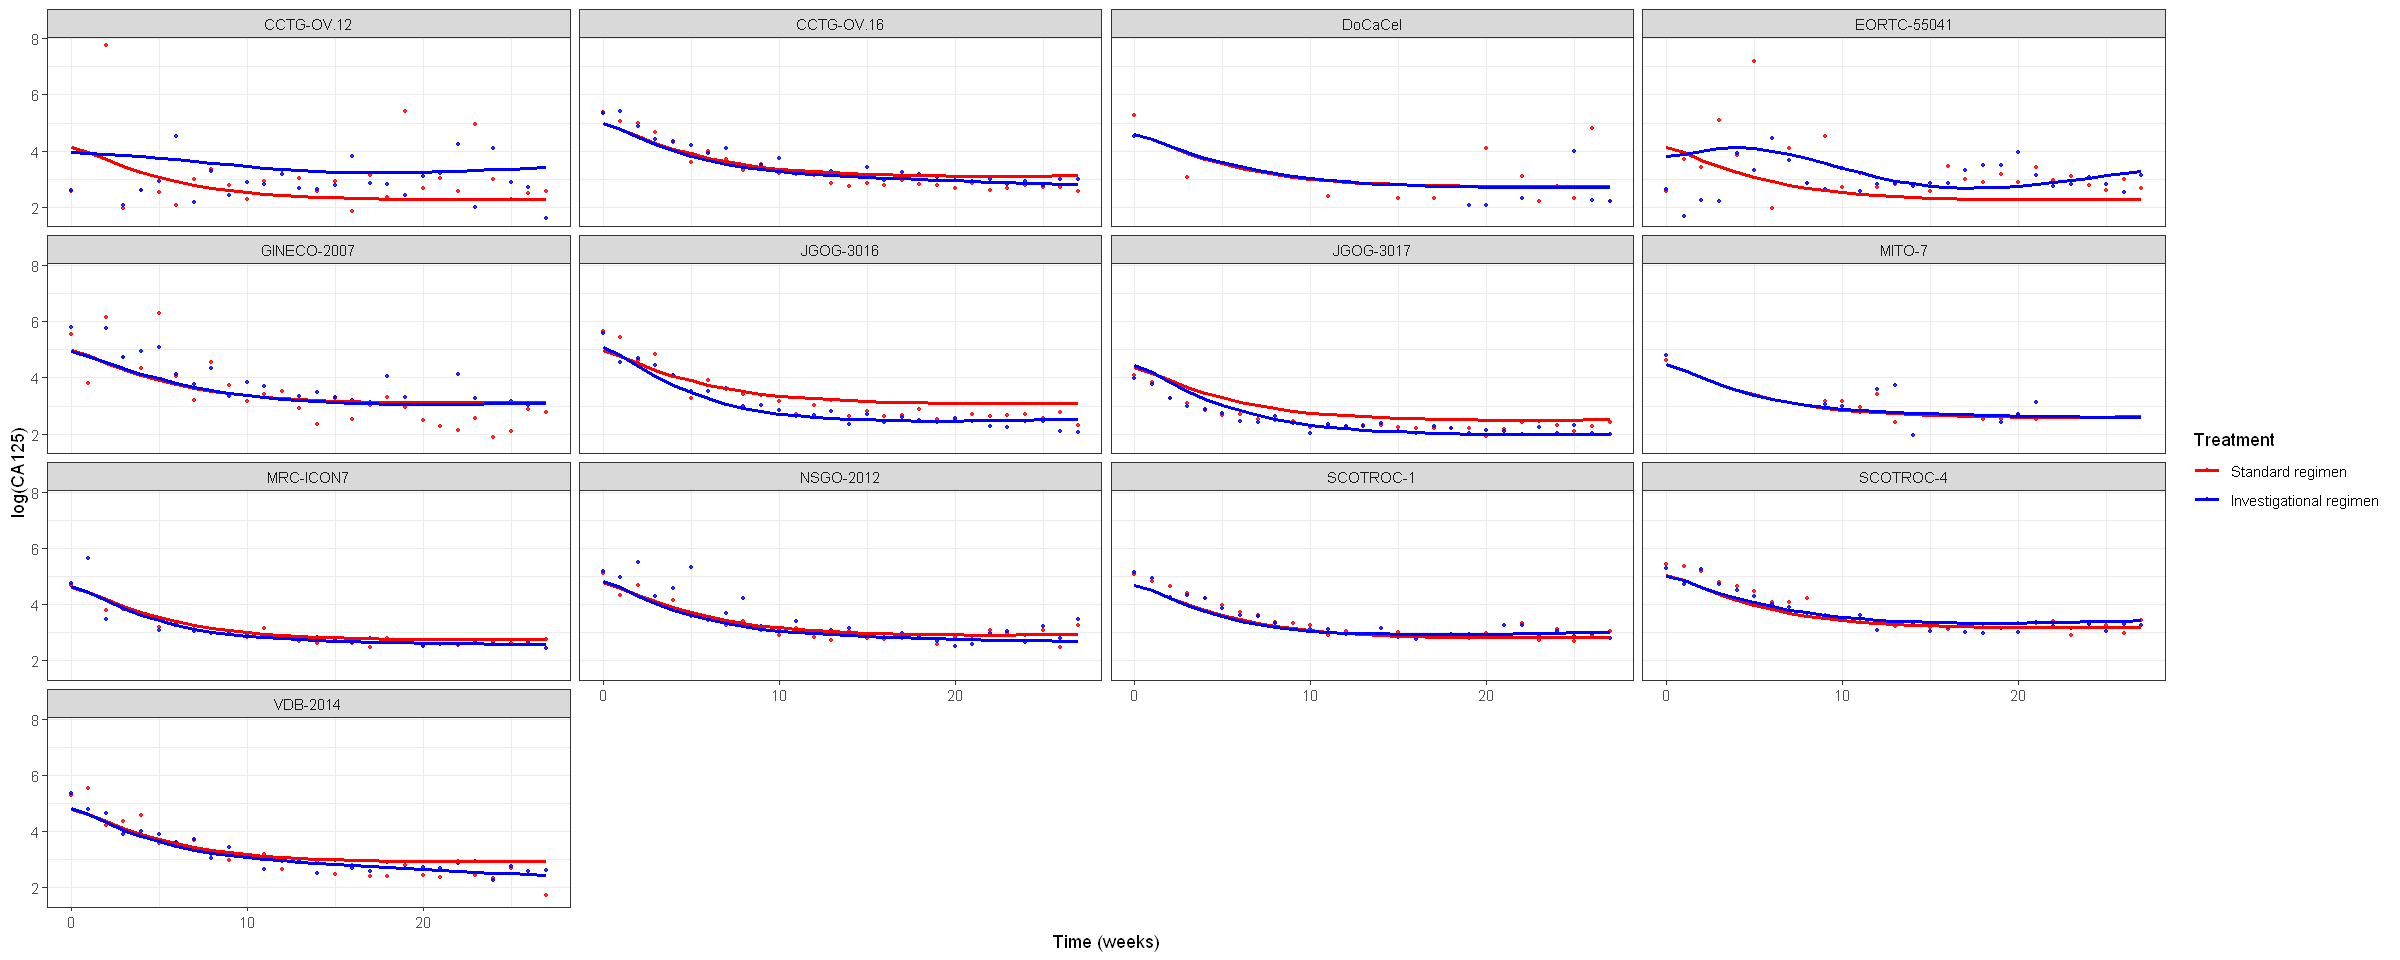

In [ ]:
options(repr.plot.width = 20, repr.plot.height = 8)

ggplot() +

  geom_point(
    data = ca125_all_6 %>%
      mutate(week = round(time_ca125 / 7)) %>%
      group_by(trialid, trt_bin, week) %>%
      summarise(
        mean_log_ca125 = mean(log_ca125, na.rm = TRUE),
        n = sum(!is.na(log_ca125)),
        .groups = "drop"
      ),

    aes(
      x = week,
      y = mean_log_ca125,
      colour = factor(trt_bin)
    ),

    alpha = 0.8,
    size = 0.8
  ) +

  geom_line(
    data = trajectory_df %>%
      mutate(week = round(time_ca125 / 7)) %>%
      group_by(trialid, trt_bin, week) %>%
      summarise(
        mean_pred = mean(pred, na.rm = TRUE),
        n = sum(!is.na(pred)),
        .groups = "drop"
      ),

    aes(
      x = week,
      y = mean_pred,
      colour = factor(trt_bin)
    ),

    linewidth = 1
  ) +

  facet_wrap(~ trialid) +

  labs(
    x = "Time (weeks)",
    y = "log(CA125)",
    colour = "Treatment"
  ) +

  scale_color_manual(
    values = c(
      "0" = "red",
      "1" = "blue"
    ),
    labels = c(
      "0" = "Standard regimen",
      "1" = "Investigational regimen"
    )
  ) +

  scale_linetype_discrete(
    labels = c(
      "0" = "Standard regimen",
      "1" = "Investigational regimen"
    )
  ) +theme_bw()

In [ ]:
auc_trap <- function(time, y) {

  sum(
    diff(time) *
      (head(y, -1) + tail(y, -1)) / 2,
    na.rm = TRUE
  )
}
month_days <- c(30, 60, 90, 120, 150, 180)

nearest_idx <- sapply(
  month_days,
  function(t)
    which.min(abs(time_grid - t))
)
compute_trial_summary <- function(s, j) {

  pred <- predict_one_draw(s, j)

  y_ctrl <- pred$ctrl
  y_trt  <- pred$trt

  # -------------------------
  # Nadir
  # -------------------------

  nadir_ctrl <- min(y_ctrl, na.rm = TRUE)
  nadir_trt  <- min(y_trt, na.rm = TRUE)

  delta_nadir <- nadir_trt - nadir_ctrl


  # -------------------------
  # Time to nadir
  # -------------------------

  t_nadir_ctrl <- time_grid[which.min(y_ctrl)]
  t_nadir_trt  <- time_grid[which.min(y_trt)]

  delta_time_nadir <-
    t_nadir_trt - t_nadir_ctrl


  # -------------------------
  # AUC
  # -------------------------

  auc_ctrl <- auc_trap(time_grid, y_ctrl)
  auc_trt  <- auc_trap(time_grid, y_trt)

  delta_auc <- auc_trt - auc_ctrl


  # -------------------------
  # Percent reductions
  # -------------------------

  pct_ctrl <- (
    y_ctrl[1] - y_ctrl[nearest_idx]
  ) / y_ctrl[1]

  pct_trt <- (
    y_trt[1] - y_trt[nearest_idx]
  ) / y_trt[1]

  delta_pct <- pct_trt - pct_ctrl


  # -------------------------
  # Monthly slopes
  # -------------------------

  idx0 <- which.min(abs(time_grid - 0))

  interval_idx <-
    c(idx0, nearest_idx)

  slope_ctrl <- numeric(6)
  slope_trt  <- numeric(6)

  for (m in 1:6) {

    i0 <- interval_idx[m]
    i1 <- interval_idx[m + 1]

    dt <- time_grid[i1] - time_grid[i0]

    slope_ctrl[m] <-
      (y_ctrl[i1] - y_ctrl[i0]) / dt

    slope_trt[m] <-
      (y_trt[i1] - y_trt[i0]) / dt
  }

  delta_slope <- slope_trt - slope_ctrl


  # -------------------------
  # Absolute differences
  # -------------------------

  abs_diff <-
    y_trt[nearest_idx] -
    y_ctrl[nearest_idx]



  data.frame(
    sample = s,
    trialid_num = j,

    delta_nadir = delta_nadir,
    delta_time_nadir = delta_time_nadir,
    delta_auc = delta_auc,

    pct_m1 = delta_pct[1],
    pct_m2 = delta_pct[2],
    pct_m3 = delta_pct[3],
    pct_m4 = delta_pct[4],
    pct_m5 = delta_pct[5],
    pct_m6 = delta_pct[6],

    slope_m1 = delta_slope[1],
    slope_m2 = delta_slope[2],
    slope_m3 = delta_slope[3],
    slope_m4 = delta_slope[4],
    slope_m5 = delta_slope[5],
    slope_m6 = delta_slope[6],

    absolutediff_m1 = abs_diff[1],
    absolutediff_m2 = abs_diff[2],
    absolutediff_m3 = abs_diff[3],
    absolutediff_m4 = abs_diff[4],
    absolutediff_m5 = abs_diff[5],
    absolutediff_m6 = abs_diff[6]
  )
}

In [ ]:
trial_samples <- bind_rows(
  lapply(seq_len(N_sample), function(s) {

    bind_rows(
      lapply(seq_len(n_trials), function(j) {
        compute_trial_summary(s, j)
      })
    )
  })
)

In [ ]:
trial_results["trialid_num"]<- as.integer(as.numeric(as.factor(trial_results$trialid)))
trial_samples<-trial_samples %>%left_join(trial_results[c("trialid_num","logHR","n_events")], by="trialid_num")

In [ ]:
surv_obj<-Surv(time = ca125_all_6_surv$pfs_time_d, event = as.numeric(ca125_all_6_surv$pfs_statut))
modele_cox <- coxph(surv_obj ~ trt_bin:strata(trialid) + strata(trialid), data = ca125_all_6_surv)
summary(modele_cox)

Call:
coxph(formula = surv_obj ~ trt_bin:strata(trialid) + strata(trialid), 
    data = ca125_all_6_surv)

  n= 7933, number of events= 5396 

                                         coef  exp(coef)   se(coef)      z
trt_bin:strata(trialid)CCTG-OV.12   0.0934225  1.0979255  0.1951064  0.479
trt_bin:strata(trialid)CCTG-OV.16   0.0459788  1.0470522  0.0801066  0.574
trt_bin:strata(trialid)DoCaCel     -0.4610536  0.6306189  0.5572105 -0.827
trt_bin:strata(trialid)EORTC-55041  0.0289915  1.0294158  0.0834015  0.348
trt_bin:strata(trialid)GINECO-2007  0.0677265  1.0700726  0.2023847  0.335
trt_bin:strata(trialid)JGOG-3016   -0.2722999  0.7616258  0.1054100 -2.583
trt_bin:strata(trialid)JGOG-3017    0.1329950  1.1422443  0.1569153  0.848
trt_bin:strata(trialid)MITO-7      -0.0603140  0.9414689  0.1218617 -0.495
trt_bin:strata(trialid)MRC-ICON7   -0.0639239  0.9380764  0.0618191 -1.034
trt_bin:strata(trialid)NSGO-2012    0.0253486  1.0256726  0.0810824  0.313
trt_bin:strata(trialid)SCOTROC-1

In [ ]:
compute_R2_one_sample <- function(df) {

  models <- list(

    nadir =
      lm(
        logHR ~ delta_nadir,
        data = df,
        weights = n_events
      ),

    time_nadir =
      lm(
        logHR ~ delta_time_nadir,
        data = df,
        weights = n_events
      ),

    auc =
      lm(
        logHR ~ delta_auc,
        data = df,
        weights = n_events
      ),

    pct1 =
      lm(logHR ~ pct_m1,
         data = df,
         weights = n_events),

    pct2 =
      lm(logHR ~ pct_m2,
         data = df,
         weights = n_events),

    pct3 =
      lm(logHR ~ pct_m3,
         data = df,
         weights = n_events),

    pct4 =
      lm(logHR ~ pct_m4,
         data = df,
         weights = n_events),

    pct5 =
      lm(logHR ~ pct_m5,
         data = df,
         weights = n_events),

    pct6 =
      lm(logHR ~ pct_m6,
         data = df,
         weights = n_events),

    slope1 =
      lm(logHR ~ slope_m1,
         data = df,
         weights = n_events),

    slope2 =
      lm(logHR ~ slope_m2,
         data = df,
         weights = n_events),

    slope3 =
      lm(logHR ~ slope_m3,
         data = df,
         weights = n_events),

    slope4 =
      lm(logHR ~ slope_m4,
         data = df,
         weights = n_events),

    slope5 =
      lm(logHR ~ slope_m5,
         data = df,
         weights = n_events),

    slope6 =
      lm(logHR ~ slope_m6,
         data = df,
         weights = n_events),

    abs1 =
      lm(logHR ~ absolutediff_m1,
         data = df,
         weights = n_events),

    abs2 =
      lm(logHR ~ absolutediff_m2,
         data = df,
         weights = n_events),

    abs3 =
      lm(logHR ~ absolutediff_m3,
         data = df,
         weights = n_events),

    abs4 =
      lm(logHR ~ absolutediff_m4,
         data = df,
         weights = n_events),

    abs5 =
      lm(logHR ~ absolutediff_m5,
         data = df,
         weights = n_events),

    abs6 =
      lm(logHR ~ absolutediff_m6,
         data = df,
         weights = n_events)
  )

  sapply(
    models,
    function(m)
      summary(m)$r.squared
  )
}
R2_samples <- trial_samples %>%
  split(.$sample) %>%
  lapply(compute_R2_one_sample) %>%
  do.call(rbind, .)

R2_samples <- as.data.frame(R2_samples)

R2_samples$sample <- seq_len(N_sample)
R2_summary <- R2_samples %>%
  pivot_longer(
    -sample,
    names_to = "surrogate",
    values_to = "R2"
  ) %>%
  group_by(surrogate) %>%
  summarise(
    mean = mean(R2, na.rm = TRUE),
    median = median(R2, na.rm = TRUE),
    lower_95 = quantile(R2, 0.025, na.rm = TRUE),
    upper_95 = quantile(R2, 0.975, na.rm = TRUE),
    .groups = "drop"
  )
# R2_summary

In [ ]:
ids<-ca125_all_6 %>%
  distinct(trialid_num, trialid) %>%
  filter(trialid %in% unique(kelim$trial_name))

In [ ]:
#kelim data
trial_samples_kelim <- trial_samples %>%
  filter(trialid_num %in% ids$trialid_num)
R2_samples_kelim <- trial_samples_kelim %>%
  split(.$sample) %>%
  lapply(compute_R2_one_sample) %>%
  do.call(rbind, .) %>%
  as.data.frame()

R2_samples_kelim$sample <- seq_len(nrow(R2_samples_kelim))
R2_summary_kelim <- R2_samples_kelim %>%
  tidyr::pivot_longer(
    cols = -sample,
    names_to = "surrogate",
    values_to = "R2"
  ) %>%
  dplyr::group_by(surrogate) %>%
  dplyr::summarise(
    mean     = mean(R2, na.rm = TRUE),
    median   = median(R2, na.rm = TRUE),
    lower_95 = quantile(R2, 0.025, na.rm = TRUE),
    upper_95 = quantile(R2, 0.975, na.rm = TRUE),
    .groups = "drop"
  )
# R2_summary_kelim

In [ ]:
cbind(
  R2_summary %>%
    mutate(
      dataset = "All 13 trials",
      R2 = sprintf("%.2f [%.2f, %.2f]", mean, lower_95, upper_95)
    ) %>%
    select(dataset, surrogate, R2),

  R2_summary_kelim%>%
    mutate(
      dataset = "Only KELIM trials (8)",
      R2 = sprintf("%.2f [%.2f, %.2f]", mean, lower_95, upper_95)
    ) %>%
    select(dataset, surrogate, R2)
)

dataset,surrogate,R2,dataset,surrogate,R2
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
All 13 trials,abs1,"0.15 [0.11, 0.19]",Only KELIM trials (8),abs1,"0.11 [0.02, 0.25]"
All 13 trials,abs2,"0.14 [0.11, 0.19]",Only KELIM trials (8),abs2,"0.07 [0.01, 0.16]"
All 13 trials,abs3,"0.12 [0.08, 0.17]",Only KELIM trials (8),abs3,"0.05 [0.01, 0.10]"
All 13 trials,abs4,"0.12 [0.08, 0.16]",Only KELIM trials (8),abs4,"0.05 [0.01, 0.10]"
All 13 trials,abs5,"0.15 [0.11, 0.20]",Only KELIM trials (8),abs5,"0.08 [0.03, 0.15]"
All 13 trials,abs6,"0.18 [0.12, 0.25]",Only KELIM trials (8),abs6,"0.13 [0.05, 0.22]"
All 13 trials,auc,"0.15 [0.11, 0.19]",Only KELIM trials (8),auc,"0.08 [0.03, 0.14]"
All 13 trials,nadir,"0.17 [0.10, 0.23]",Only KELIM trials (8),nadir,"0.11 [0.04, 0.20]"
All 13 trials,pct1,"0.14 [0.11, 0.17]",Only KELIM trials (8),pct1,"0.11 [0.02, 0.26]"


In [ ]:
trial_samples$logHR2 <- model_fit$summary.fixed["trt_bin_S1","mean"]
trial_samples_kelim$logHR2 <- model_fit$summary.fixed["trt_bin_S1","mean"]
compute_R2_one_sample2 <- function(df) {

  models <- list(

    nadir =
      lm(
        logHR2 ~ delta_nadir,
        data = df,
        weights = n_events
      ),

    time_nadir =
      lm(
        logHR2 ~ delta_time_nadir,
        data = df,
        weights = n_events
      ),

    auc =
      lm(
        logHR2 ~ delta_auc,
        data = df,
        weights = n_events
      ),

    pct1 =
      lm(logHR2 ~ pct_m1,
         data = df,
         weights = n_events),

    pct2 =
      lm(logHR2 ~ pct_m2,
         data = df,
         weights = n_events),

    pct3 =
      lm(logHR2 ~ pct_m3,
         data = df,
         weights = n_events),

    pct4 =
      lm(logHR2 ~ pct_m4,
         data = df,
         weights = n_events),

    pct5 =
      lm(logHR2 ~ pct_m5,
         data = df,
         weights = n_events),

    pct6 =
      lm(logHR2 ~ pct_m6,
         data = df,
         weights = n_events),

    slope1 =
      lm(logHR2 ~ slope_m1,
         data = df,
         weights = n_events),

    slope2 =
      lm(logHR2 ~ slope_m2,
         data = df,
         weights = n_events),

    slope3 =
      lm(logHR2 ~ slope_m3,
         data = df,
         weights = n_events),

    slope4 =
      lm(logHR2 ~ slope_m4,
         data = df,
         weights = n_events),

    slope5 =
      lm(logHR2 ~ slope_m5,
         data = df,
         weights = n_events),

    slope6 =
      lm(logHR2 ~ slope_m6,
         data = df,
         weights = n_events),

    abs1 =
      lm(logHR2 ~ absolutediff_m1,
         data = df,
         weights = n_events),

    abs2 =
      lm(logHR2 ~ absolutediff_m2,
         data = df,
         weights = n_events),

    abs3 =
      lm(logHR2 ~ absolutediff_m3,
         data = df,
         weights = n_events),

    abs4 =
      lm(logHR2 ~ absolutediff_m4,
         data = df,
         weights = n_events),

    abs5 =
      lm(logHR2 ~ absolutediff_m5,
         data = df,
         weights = n_events),

    abs6 =
      lm(logHR2 ~ absolutediff_m6,
         data = df,
         weights = n_events)
  )

  sapply(
    models,
    function(m)
      summary(m)$r.squared
  )
}
R2_samples2 <- trial_samples %>%
  split(.$sample) %>%
  lapply(compute_R2_one_sample2) %>%
  do.call(rbind, .)

R2_samples2 <- as.data.frame(R2_samples2)

R2_samples2$sample <- seq_len(N_sample)
R2_summary2 <- R2_samples2 %>%
  pivot_longer(
    -sample,
    names_to = "surrogate",
    values_to = "R2"
  ) %>%
  group_by(surrogate) %>%
  summarise(
    mean = mean(R2, na.rm = TRUE),
    median = median(R2, na.rm = TRUE),
    lower_95 = quantile(R2, 0.025, na.rm = TRUE),
    upper_95 = quantile(R2, 0.975, na.rm = TRUE),
    .groups = "drop"
  )
#kelim data
R2_samples_kelim2 <- trial_samples_kelim %>%
  split(.$sample) %>%
  lapply(compute_R2_one_sample2) %>%
  do.call(rbind, .) %>%
  as.data.frame()

R2_samples_kelim2$sample <- seq_len(nrow(R2_samples_kelim2))
R2_summary_kelim2 <- R2_samples_kelim2 %>%
  tidyr::pivot_longer(
    cols = -sample,
    names_to = "surrogate",
    values_to = "R2"
  ) %>%
  dplyr::group_by(surrogate) %>%
  dplyr::summarise(
    mean     = mean(R2, na.rm = TRUE),
    median   = median(R2, na.rm = TRUE),
    lower_95 = quantile(R2, 0.025, na.rm = TRUE),
    upper_95 = quantile(R2, 0.975, na.rm = TRUE),
    .groups = "drop"
  )
cbind(
  R2_summary2 %>%
    mutate(
      dataset = "All 13 trials",
      R2 = sprintf("%.2f [%.2f, %.2f]", mean, lower_95, upper_95)
    ) %>%
    select(dataset, surrogate, R2),

  R2_summary_kelim2%>%
    mutate(
      dataset = "Only KELIM trials (8)",
      R2 = sprintf("%.2f [%.2f, %.2f]", mean, lower_95, upper_95)
    ) %>%
    select(dataset, surrogate, R2)
)

dataset,surrogate,R2,dataset,surrogate,R2
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
All 13 trials,abs1,"0.46 [0.45, 0.47]",Only KELIM trials (8),abs1,"0.53 [0.50, 0.59]"
All 13 trials,abs2,"0.46 [0.45, 0.46]",Only KELIM trials (8),abs2,"0.54 [0.50, 0.58]"
All 13 trials,abs3,"0.46 [0.45, 0.56]",Only KELIM trials (8),abs3,"0.55 [0.51, 0.58]"
All 13 trials,abs4,"0.50 [0.45, 0.56]",Only KELIM trials (8),abs4,"0.55 [0.51, 0.57]"
All 13 trials,abs5,"0.51 [0.45, 0.56]",Only KELIM trials (8),abs5,"0.53 [0.50, 0.57]"
All 13 trials,abs6,"0.50 [0.45, 0.56]",Only KELIM trials (8),abs6,"0.52 [0.50, 0.57]"
All 13 trials,auc,"0.45 [0.45, 0.45]",Only KELIM trials (8),auc,"0.54 [0.51, 0.57]"
All 13 trials,nadir,"0.51 [0.51, 0.52]",Only KELIM trials (8),nadir,"0.52 [0.50, 0.57]"
All 13 trials,pct1,"0.46 [0.46, 0.47]",Only KELIM trials (8),pct1,"0.53 [0.50, 0.58]"


In [ ]:
results <- ca125_all_6_surv %>%
  group_by(trialid_num) %>%
  group_modify(~ {

    fit <- coxph(
      Surv(pfs_time_d, as.numeric(pfs_statut)) ~ trt_bin,
      data = .x
    )

    tibble(
      logHR3 = unname(coef(fit)["trt_bin"]),
      SE_logHR = sqrt(vcov(fit)["trt_bin", "trt_bin"]),
      n_events2 = sum(.x$pfs_statut == 1, na.rm = TRUE)
    )
  }) %>%
  ungroup()
  trial_samples3 <- trial_samples %>%
  left_join(
    results %>% select(trialid_num, logHR3, n_events2),
    by = "trialid_num"
  )
trial_samples_kelim3 <- trial_samples3 %>%
  filter(trialid_num %in% ids$trialid_num)
compute_R2_one_sample3 <- function(df) {

  models <- list(

    nadir =
      lm(
        logHR3 ~ delta_nadir,
        data = df,
        weights = n_events2
      ),

    time_nadir =
      lm(
        logHR3 ~ delta_time_nadir,
        data = df,
        weights = n_events2
      ),

    auc =
      lm(
        logHR3 ~ delta_auc,
        data = df,
        weights = n_events2
      ),

    pct1 =
      lm(logHR3 ~ pct_m1,
         data = df,
         weights = n_events2),

    pct2 =
      lm(logHR3 ~ pct_m2,
         data = df,
         weights = n_events2),

    pct3 =
      lm(logHR3 ~ pct_m3,
         data = df,
         weights = n_events2),

    pct4 =
      lm(logHR3 ~ pct_m4,
         data = df,
         weights = n_events2),

    pct5 =
      lm(logHR3 ~ pct_m5,
         data = df,
         weights = n_events2),

    pct6 =
      lm(logHR3 ~ pct_m6,
         data = df,
         weights = n_events2),

    slope1 =
      lm(logHR3 ~ slope_m1,
         data = df,
         weights = n_events2),

    slope2 =
      lm(logHR3 ~ slope_m2,
         data = df,
         weights = n_events2),

    slope3 =
      lm(logHR3 ~ slope_m3,
         data = df,
         weights = n_events2),

    slope4 =
      lm(logHR3 ~ slope_m4,
         data = df,
         weights = n_events2),

    slope5 =
      lm(logHR3 ~ slope_m5,
         data = df,
         weights = n_events2),

    slope6 =
      lm(logHR3 ~ slope_m6,
         data = df,
         weights = n_events2),

    abs1 =
      lm(logHR3 ~ absolutediff_m1,
         data = df,
         weights = n_events2),

    abs2 =
      lm(logHR3 ~ absolutediff_m2,
         data = df,
         weights = n_events2),

    abs3 =
      lm(logHR3 ~ absolutediff_m3,
         data = df,
         weights = n_events2),

    abs4 =
      lm(logHR3 ~ absolutediff_m4,
         data = df,
         weights = n_events2),

    abs5 =
      lm(logHR3 ~ absolutediff_m5,
         data = df,
         weights = n_events2),

    abs6 =
      lm(logHR3 ~ absolutediff_m6,
         data = df,
         weights = n_events2)
  )

  sapply(
    models,
    function(m)
      summary(m)$r.squared
  )
}
R2_samples3 <- trial_samples3 %>%
  split(.$sample) %>%
  lapply(compute_R2_one_sample3) %>%
  do.call(rbind, .)

R2_samples3 <- as.data.frame(R2_samples3)

R2_samples3$sample <- seq_len(N_sample)
R2_summary3 <- R2_samples3 %>%
  pivot_longer(
    -sample,
    names_to = "surrogate",
    values_to = "R2"
  ) %>%
  group_by(surrogate) %>%
  summarise(
    mean = mean(R2, na.rm = TRUE),
    median = median(R2, na.rm = TRUE),
    lower_95 = quantile(R2, 0.025, na.rm = TRUE),
    upper_95 = quantile(R2, 0.975, na.rm = TRUE),
    .groups = "drop"
  )
#kelim data
R2_samples_kelim3 <- trial_samples_kelim3 %>%
  split(.$sample) %>%
  lapply(compute_R2_one_sample3) %>%
  do.call(rbind, .) %>%
  as.data.frame()

R2_samples_kelim3$sample <- seq_len(nrow(R2_samples_kelim3))
R2_summary_kelim3 <- R2_samples_kelim3 %>%
  tidyr::pivot_longer(
    cols = -sample,
    names_to = "surrogate",
    values_to = "R2"
  ) %>%
  dplyr::group_by(surrogate) %>%
  dplyr::summarise(
    mean     = mean(R2, na.rm = TRUE),
    median   = median(R2, na.rm = TRUE),
    lower_95 = quantile(R2, 0.025, na.rm = TRUE),
    upper_95 = quantile(R2, 0.975, na.rm = TRUE),
    .groups = "drop"
  )
cbind(
  R2_summary3 %>%
    mutate(
      dataset = "All 13 trials",
      R2 = sprintf("%.2f [%.2f, %.2f]", mean, lower_95, upper_95)
    ) %>%
    select(dataset, surrogate, R2),

  R2_summary_kelim3 %>%
    mutate(
      dataset = "Only KELIM trials (8)",
      R2 = sprintf("%.2f [%.2f, %.2f]", mean, lower_95, upper_95)
    ) %>%
    select(dataset, surrogate, R2)
)


dataset,surrogate,R2,dataset,surrogate,R2
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
All 13 trials,abs1,"0.16 [0.12, 0.20]",Only KELIM trials (8),abs1,"0.40 [0.24, 0.54]"
All 13 trials,abs2,"0.21 [0.16, 0.25]",Only KELIM trials (8),abs2,"0.40 [0.28, 0.51]"
All 13 trials,abs3,"0.28 [0.22, 0.33]",Only KELIM trials (8),abs3,"0.36 [0.27, 0.44]"
All 13 trials,abs4,"0.27 [0.22, 0.32]",Only KELIM trials (8),abs4,"0.29 [0.21, 0.36]"
All 13 trials,abs5,"0.20 [0.16, 0.25]",Only KELIM trials (8),abs5,"0.20 [0.13, 0.28]"
All 13 trials,abs6,"0.14 [0.10, 0.19]",Only KELIM trials (8),abs6,"0.12 [0.05, 0.21]"
All 13 trials,auc,"0.22 [0.18, 0.26]",Only KELIM trials (8),auc,"0.29 [0.21, 0.37]"
All 13 trials,nadir,"0.18 [0.13, 0.24]",Only KELIM trials (8),nadir,"0.15 [0.08, 0.24]"
All 13 trials,pct1,"0.13 [0.10, 0.16]",Only KELIM trials (8),pct1,"0.36 [0.20, 0.51]"
